
<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. Environment Preparation</h2>
<p>I executed <strong>Runtime → Run all</strong> using the free CPU runtime. The setup downloaded pinned course files, verified SHA-256 hashes and retried temporary network failures.</p>
<ul><li><code>FAST_MODE=True</code>: up to 300 trees and two CPU threads; used for the initial run.</li><li><code>FULL_MODE=True</code>: optional cap of 900 trees after saving the baseline run.</li><li>No GPU, API key, Drive mount or paid subscription was required.</li></ul>
<p><strong>Verification:</strong> the setup printed <code>Day 1 setup verified</code>. Checksum or imported-version failures were not bypassed; the session must be restarted and the notebook rerun from the beginning if such failures occur.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. إعداد بيئة التشغيل</h2>
<p>شغّلت <strong>Runtime → Run all</strong> باستخدام CPU المجاني. نزّل الإعداد ملفات الدورة ذات الإصدارات المثبتة، وتحقق من بصمات SHA-256، وأعاد محاولة أخطاء الشبكة المؤقتة.</p>
<ul><li><code>FAST_MODE=True</code>: حتى 300 شجرة وخيطَي CPU؛ استخدمته في التشغيل الأولي.</li><li><code>FULL_MODE=True</code>: سقف اختياري يبلغ 900 شجرة بعد حفظ تجربة الأساس.</li><li>لم أحتج إلى GPU أو مفتاح API أو ربط Drive أو اشتراك مدفوع.</li></ul>
<p><strong>التحقق:</strong> ظهرت رسالة <code>Day 1 setup verified</code>. لم يتم تجاوز أخطاء البصمة أو اختلاف إصدارات المكتبات؛ وفي حال حدوثها يجب إعادة تشغيل الجلسة وتشغيل الدفتر من البداية.</p>
</td>
</tr>
</table>


In [40]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "c8344f6b19b26dcbce3dcfc671b746c59bf55895"
LAB_SHA256 = "2a968ba9e738cc5e3dae12077e576fdb40ec6ec64230613e445bbc7884e7e1ba"
fetch_verified(
    f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/scripts/day1_lab.py",
    ROOT / "scripts/day1_lab.py", LAB_SHA256)
print("Day 1 setup verified | إعداد اليوم الأول جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 1 setup verified | إعداد اليوم الأول جاهز



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. Task and Data Understanding</h2>
<p>All records are synthetic. The target <code>default_within_90d</code> indicates whether a default event occurs within 90 days after the application; it does not represent a delay of exactly 90 days.</p>
<ul><li>I used 22 features available at application time.</li><li>I excluded identifiers, dates, split-control columns and the target from model inputs.</li><li>Missing-value imputation was learned from training rows only.</li><li>Challenge data was not used in this lab.</li></ul>
<p><strong>Problem definition:</strong> I defined the outcome being estimated, the decision time and the intended educational use. This simulation is not intended for real financing decisions.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. فهم المهمة والبيانات</h2>
<p>جميع السجلات اصطناعية. يشير الهدف <code>default_within_90d</code> إلى وقوع حدث تعثر خلال 90 يومًا بعد تقديم الطلب، ولا يعني تأخرًا مدته 90 يومًا بالضبط.</p>
<ul><li>استخدمت 22 خاصية متاحة وقت تقديم الطلب.</li><li>استبعدت المعرّفات والتواريخ وأعمدة التحكم في التقسيم والهدف من مدخلات النموذج.</li><li>تم تعلّم تعويض القيم المفقودة من صفوف التدريب فقط.</li><li>لم أستخدم بيانات التحدي في هذا الجزء من المشروع.</li></ul>
<p><strong>تعريف المشكلة:</strong> حددت النتيجة المراد التنبؤ بها، ووقت اتخاذ القرار، والاستخدام التعليمي المقصود. هذه المحاكاة غير مخصصة لاتخاذ قرارات تمويل فعلية.</p>
</td>
</tr>
</table>


In [41]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_curve, precision_recall_curve
from data_checks import load_course_data
from day1_lab import (LabConfig, MODEL_NAMES, make_splits, select_tree_count,
                      fit_model, compare_models, learner_checkpoint, config_dict)

warnings.filterwarnings("ignore", message="scipy.optimize:.*disp.*", category=DeprecationWarning)
frames, contract, data_summary = load_course_data(ROOT)
train = frames["train"]
FAST_MODE, FULL_MODE = True, False  # Choose exactly one mode.
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = LabConfig(max_trees=300 if FAST_MODE else 900)
X, y, splits = make_splits(train, contract, seed=config.seed)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(pd.DataFrame({"rows": [len(train)], "predictors": [X.shape[1]],
                      "positive_rate": [y.mean()], "missing_cells": [int(X.isna().sum().sum())]}))
display(train[["application_id", "income_sar", "bureau_score", contract["target"]["name"]]].head(3))

,rows,predictors,positive_rate,missing_cells
0,10000,22,0.0789,766


,application_id,income_sar,bureau_score,default_within_90d
0,TR-001121,8938.11,584.0,0
1,TR-002836,16995.65,652.0,0
2,TR-005579,8353.27,734.0,0



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. Data Role Separation Before Model Training</h2>
<p>I divided the 10,000 applications into distinct data roles:</p>
<table><tr><th>Role</th><th>Rows</th><th>Purpose</th></tr><tr><td>Inner fit</td><td>6,000</td><td>Fit preprocessing and trees while selecting their count</td></tr><tr><td>Inner stop</td><td>2,000</td><td>Select the number of trees using log loss</td></tr><tr><td>Development</td><td>8,000</td><td>Refit each model after internal decisions are fixed</td></tr><tr><td>Comparison</td><td>2,000</td><td>Score all models once after fitting</td></tr></table>
<p>The inner sets were contained within the development set and were not additional data. I kept the comparison set separate from early stopping and repeated tuning. This separation improved the model comparison, while customer and time leakage remained intentionally unresolved until Day 2.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. فصل أدوار البيانات قبل تدريب النماذج</h2>
<p>قسّمت الطلبات البالغ عددها 10,000 إلى أدوار منفصلة:</p>
<table><tr><th>الدور</th><th>الصفوف</th><th>الغرض</th></tr><tr><td>Inner fit</td><td>6,000</td><td>تعلم المعالجة والأشجار أثناء اختيار عددها</td></tr><tr><td>Inner stop</td><td>2,000</td><td>اختيار عدد الأشجار باستخدام log loss</td></tr><tr><td>Development</td><td>8,000</td><td>إعادة تدريب كل نموذج بعد تثبيت القرارات الداخلية</td></tr><tr><td>Comparison</td><td>2,000</td><td>تقييم جميع النماذج مرة واحدة بعد التدريب</td></tr></table>
<p>كانت المجموعتان الداخليتان جزءًا من مجموعة التطوير وليستا بيانات إضافية. أبقيت مجموعة المقارنة منفصلة عن الإيقاف المبكر والضبط المتكرر. ساعد هذا الفصل على تحسين مقارنة النماذج، بينما بقي تسرب بيانات العملاء والزمن دون معالجة عمدًا حتى اليوم الثاني.</p>
</td>
</tr>
</table>


In [42]:
development, comparison = splits["development"], splits["comparison"]
inner_fit, inner_stop = splits["inner_fit"], splits["inner_stop"]
assert not (set(development) & set(comparison))
assert not (set(inner_fit) & set(inner_stop))
split_table = pd.DataFrame([
    {"role": role, "rows": len(index), "positive_rate": y.loc[index].mean()}
    for role, index in splits.items()
])
shared_customers = len(set(train.loc[development, "customer_id"]) & set(train.loc[comparison, "customer_id"]))
display(split_table)
print(f"Customers shared across development/comparison: {shared_customers} — revisit on Day 2")
models, timings, selections = {}, {}, {}

,role,rows,positive_rate
0,development,8000,0.078875
1,comparison,2000,0.079000
2,inner_fit,6000,0.078833
3,inner_stop,2000,0.079000


Customers shared across development/comparison: 1226 — revisit on Day 2



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. Baseline Model Development</h2>
<p>I developed a baseline using a single Pipeline combining median imputation, feature scaling and Logistic Regression. All learned preprocessing values were obtained from development rows only.</p>
<p><strong>Importance:</strong> I used this simple, reliable baseline as a reference to evaluate whether more complex models provided additional value. Model complexity alone was not considered evidence of improvement.</p>
<p><strong>Evaluation:</strong> I examined training time, ROC-AUC and Average Precision. The baseline remained a valid comparison model despite not using trees.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. تطوير النموذج الأساسي</h2>
<p>طوّرت نموذجًا أساسيًا باستخدام Pipeline واحدة تجمع التعويض بالوسيط وتوحيد المقاييس وLogistic Regression. تم تعلّم جميع قيم المعالجة من صفوف التطوير فقط.</p>
<p><strong>الأهمية:</strong> استخدمت هذا النموذج البسيط والموثوق مرجعًا لتقييم ما إذا كانت النماذج الأكثر تعقيدًا تقدم قيمة إضافية. ولم أعتبر تعقيد النموذج وحده دليلًا على التحسن.</p>
<p><strong>التقييم:</strong> فحصت زمن التدريب وROC-AUC وAverage Precision. وظل النموذج الأساسي مرجعًا صالحًا للمقارنة رغم عدم استخدامه للأشجار.</p>
</td>
</tr>
</table>


In [43]:
name = "Logistic Regression"
models[name], timings[name] = fit_model(name, X.loc[development], y.loc[development], config)
print(f"Baseline fitted on {len(development):,} rows in {timings[name]['train_seconds']:.3f} s")

Baseline fitted on 8,000 rows in 0.181 s



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. Boosting Comparison with Early Stopping</h2>
<p>I compared boosting models that add trees sequentially to reduce the objective. Under logistic classification, tree contributions accumulate in log-odds space before conversion to probability; the model does not directly sum tree probabilities.</p>
<table><tr><th>Control</th><th>What I examined</th></tr><tr><td><code>learning_rate</code></td><td>Contribution of each tree; a smaller value may require more trees</td></tr><tr><td><code>max_trees</code></td><td>Search ceiling, not a mandatory tree count</td></tr><tr><td><code>xgb_depth</code> / <code>lgb_leaves</code></td><td>Tree complexity</td></tr><tr><td><code>min_child_samples</code></td><td>Prevention of very small LightGBM leaves</td></tr><tr><td><code>patience</code></td><td>Rounds without improvement in inner-stop log loss</td></tr></table>
<p>I used one-based indexing for <code>selected_trees</code>. Logistic Regression had no tree count. I intentionally deferred class weights to a later lab.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. مقارنة نماذج التعزيز باستخدام الإيقاف المبكر</h2>
<p>قارنت نماذج التعزيز التي تضيف أشجارًا بالتتابع لتقليل دالة الهدف. في التصنيف اللوجستي تتراكم إسهامات الأشجار في فضاء log-odds قبل تحويلها إلى احتمال؛ ولا يجمع النموذج احتمالات الأشجار مباشرة.</p>
<table><tr><th>الإعداد</th><th>ما الذي فحصته؟</th></tr><tr><td><code>learning_rate</code></td><td>مساهمة كل شجرة؛ قد تتطلب القيمة الأصغر أشجارًا أكثر</td></tr><tr><td><code>max_trees</code></td><td>سقف البحث وليس عددًا إلزاميًا</td></tr><tr><td><code>xgb_depth</code> / <code>lgb_leaves</code></td><td>تعقيد الأشجار</td></tr><tr><td><code>min_child_samples</code></td><td>منع أوراق LightGBM الصغيرة جدًا</td></tr><tr><td><code>patience</code></td><td>عدد الجولات دون تحسن في inner-stop log loss</td></tr></table>
<p>استخدمت ترقيمًا يبدأ من 1 في <code>selected_trees</code>. لم يكن لـLogistic Regression عدد أشجار. وأجّلت أوزان الفئات عمدًا إلى لاب لاحق.</p>
</td>
</tr>
</table>


In [44]:
for name in ("XGBoost", "LightGBM"):
    selections[name] = select_tree_count(
        name, X.loc[inner_fit], y.loc[inner_fit], X.loc[inner_stop], y.loc[inner_stop], config)
    models[name], timings[name] = fit_model(
        name, X.loc[development], y.loc[development], config, selections[name])
    print(f"{name}: {selections[name]['selected_trees']} selected trees; "
          f"{selections[name]['rounds_evaluated']} evaluated rounds; "
          f"{timings[name]['train_seconds']:.3f} s including selection + refit")
    if selections[name]["hit_tree_budget"]:
        print("Tree budget reached: record this limitation before considering FULL_MODE.")

XGBoost: 61 selected trees; 91 evaluated rounds; 5.477 s including selection + refit
LightGBM: 41 selected trees; 71 evaluated rounds; 1.507 s including selection + refit



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Learning Curve Analysis</h2>
<p>I analyzed the learning curves, where the dashed line represented inner-stop loss and the vertical marker indicated the selected tree count. Decreasing training loss alone was not considered sufficient.</p>
<ul><li>I identified where inner-stop loss stopped improving.</li><li>I recorded whether the search reached the tree budget.</li><li>I did not infer general superiority from a single curve.</li></ul>
<p>I kept plot labels concise and in English to ensure consistent rendering of exported figures across environments.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>تحليل منحنيات التعلم</h2>
<p>حلّلت منحنيات التعلم، حيث مثّل الخط المتقطع خسارة inner stop، وحددت العلامة الرأسية عدد الأشجار المختار. ولم أعتبر انخفاض خسارة التدريب وحده كافيًا.</p>
<ul><li>حددت أين توقفت خسارة inner stop عن التحسن.</li><li>سجلت ما إذا وصل البحث إلى سقف الأشجار.</li><li>لم أستنتج تفوقًا عامًا من منحنى واحد.</li></ul>
<p>أبقيت عناوين الرسوم التقنية قصيرة وبالإنجليزية لضمان ثبات عرض الملفات المصدّرة عبر البيئات المختلفة.</p>
</td>
</tr>
</table>


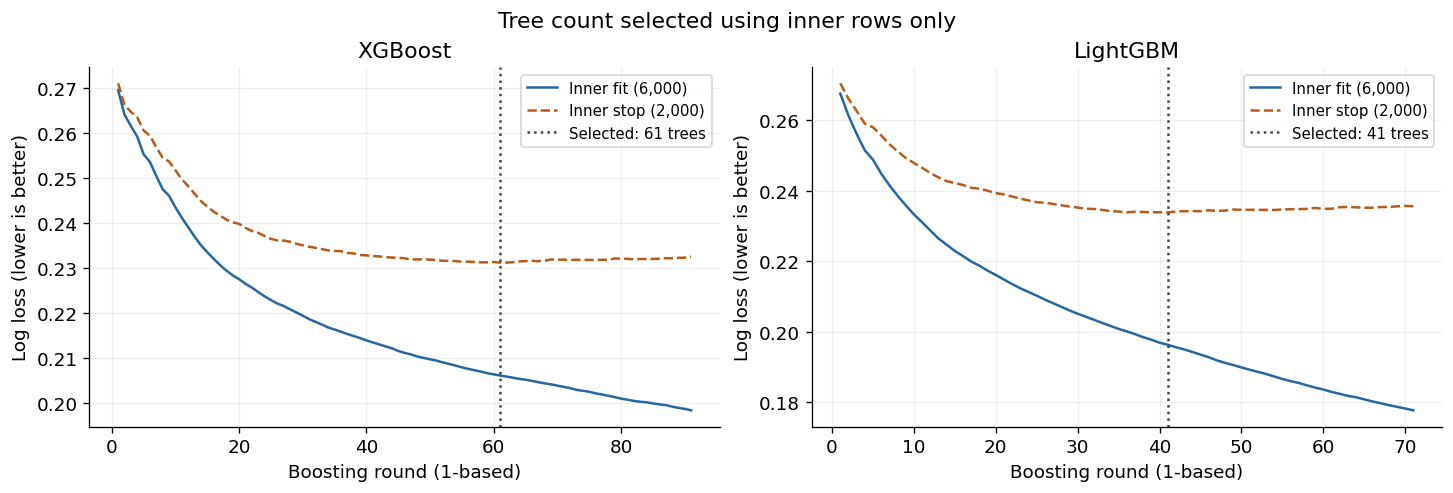

In [45]:
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
colors = {"Logistic Regression": "#2667A0", "XGBoost": "#BA5A17", "LightGBM": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, (name, result) in zip(axes, selections.items()):
    rounds = np.arange(1, len(result["curves"]["fit"]) + 1)
    ax.plot(rounds, result["curves"]["fit"], label="Inner fit (6,000)", color="#2667A0")
    ax.plot(rounds, result["curves"]["stop"], label="Inner stop (2,000)", color="#BA5A17", linestyle="--")
    ax.axvline(result["selected_trees"], color="#444444", linestyle=":",
               label=f"Selected: {result['selected_trees']} trees")
    ax.set(title=name, xlabel="Boosting round (1-based)", ylabel="Log loss (lower is better)")
    ax.legend(fontsize=9)
fig.suptitle("Tree count selected using inner rows only")
fig.savefig(ARTIFACTS / "day1_learning_curves.png", dpi=160)
plt.show()


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. Fair Comparison of the Three Models</h2>
<p>I used <strong>ROC-AUC</strong> to evaluate the ranking of positive versus negative cases across thresholds. I also used <strong>Average Precision (AP)</strong> to evaluate precision–recall performance, particularly because the positive class was uncommon. In this project, PR-AUC refers to scikit-learn Average Precision, not trapezoidal area.</p>
<p>I measured <code>train_seconds</code>, including tree-count selection and refitting for boosting models, and fitting for Logistic Regression. Download and plotting time were excluded. The recorded timing reflects this specific run and does not guarantee identical performance on other hardware.</p>
<p>This single-split comparison did not include confidence intervals or establish calibration, operational value or general superiority. I deferred the simulated decision cost <code>10 × FN + FP</code> and 12% review capacity to a later decision lab.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. المقارنة العادلة بين النماذج الثلاثة</h2>
<p>استخدمت <strong>ROC-AUC</strong> لتقييم ترتيب الحالات الموجبة مقابل السالبة عبر العتبات. واستخدمت أيضًا <strong>Average Precision (AP)</strong> لتقييم أداء precision–recall، خصوصًا بسبب ندرة الفئة الموجبة. في هذا المشروع يشير PR-AUC إلى Average Precision في scikit-learn، وليس المساحة شبه المنحرفة.</p>
<p>قست <code>train_seconds</code> بما يشمل اختيار عدد الأشجار وإعادة التدريب لنماذج التعزيز، وتدريب Logistic Regression. استبعدت زمن التنزيل والرسم. يعكس الزمن المسجل هذا التشغيل تحديدًا ولا يضمن الأداء نفسه على أجهزة أخرى.</p>
<p>لم تتضمن هذه المقارنة باستخدام تقسيم واحد فترات ثقة، ولم تثبت المعايرة أو القيمة التشغيلية أو التفوق العام. وأجّلت تكلفة القرار التعليمية <code>10 × FN + FP</code> وسعة المراجعة البالغة 12% إلى لاب قرار لاحق.</p>
</td>
</tr>
</table>


In [46]:
comparison_table, probabilities = compare_models(
    models, timings, selections, X.loc[comparison], y.loc[comparison])
comparison_table["selected_trees"] = comparison_table["selected_trees"].astype("Int64")
display(comparison_table[["model", "roc_auc", "average_precision", "train_seconds",
                          "selected_trees", "comparison_rows", "positive_rate"]].round(4))
comparison_table.to_csv(ARTIFACTS / "day1_model_comparison.csv", index=False)
prediction_export = train.loc[comparison, ["application_id", "default_within_90d"]].join(probabilities)
prediction_export.to_csv(ARTIFACTS / "day1_comparison_predictions.csv", index=False)
assert len(comparison_table) == 3
assert comparison_table[["roc_auc", "average_precision", "train_seconds"]].notna().all().all()
print("TECHNICAL_READY — three models compared; your interpretation is still required.")

,model,roc_auc,average_precision,train_seconds,selected_trees,comparison_rows,positive_rate
0,Logistic Regression,0.8213,0.3258,0.1809,<NA>,2000,0.079
1,XGBoost,0.8124,0.3338,5.4767,61,2000,0.079
2,LightGBM,0.8138,0.3248,1.5069,41,2000,0.079


TECHNICAL_READY — three models compared; your interpretation is still required.



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>ROC and Precision–Recall Curve Analysis</h2>
<p>I analyzed the ROC and precision–recall curves together. The ROC reference line represented random ranking, while the precision reference line corresponded to the positive prevalence in the comparison sample.</p>
<ul><li>I compared curve separation rather than relying on a single headline metric.</li><li>I examined precision when recall was high.</li><li>I referred to the results table for exact values and sample context.</li></ul>
<p>I treated a visually higher curve on a single random split as evidence specific to this run only.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>تحليل منحنيات ROC وPrecision–Recall</h2>
<p>حلّلت منحنيات ROC وprecision–recall معًا. مثّل الخط المرجعي في ROC ترتيبًا عشوائيًا، بينما مثّل خط precision المرجعي نسبة الفئة الموجبة في عينة المقارنة.</p>
<ul><li>قارنت تباعد المنحنيات بدلًا من الاعتماد على مقياس رئيسي واحد فقط.</li><li>فحصت precision عندما كان recall مرتفعًا.</li><li>رجعت إلى جدول النتائج للاطلاع على القيم الدقيقة وسياق حجم العينة.</li></ul>
<p>اعتبرت ارتفاع أحد المنحنيات بصريًا في تقسيم عشوائي واحد دليلًا يخص هذا التشغيل فقط.</p>
</td>
</tr>
</table>


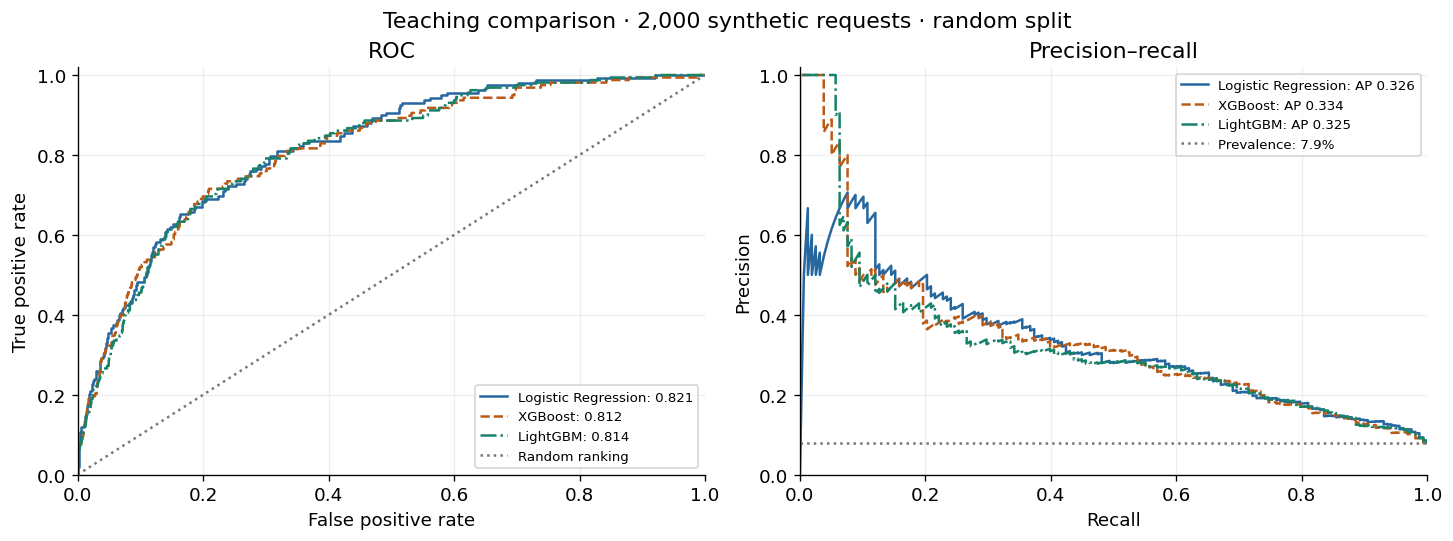

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
styles = ["-", "--", "-."]
for name, style in zip(MODEL_NAMES, styles):
    fpr, tpr, _ = roc_curve(y.loc[comparison], probabilities[name])
    precision, recall, _ = precision_recall_curve(y.loc[comparison], probabilities[name])
    row = comparison_table.set_index("model").loc[name]
    axes[0].plot(fpr, tpr, color=colors[name], linestyle=style, label=f"{name}: {row.roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[name], linestyle=style, label=f"{name}: AP {row.average_precision:.3f}")
axes[0].plot([0, 1], [0, 1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(y.loc[comparison].mean(), color="#777777", linestyle=":",
               label=f"Prevalence: {y.loc[comparison].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle(f"Teaching comparison · {len(comparison):,} synthetic requests · random split")
fig.savefig(ARTIFACTS / "day1_roc_pr.png", dpi=160)
plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. Own the model-selection decision</h2>
<p>Complete the next shared code cell in your own words. There is no automatic winner and no model is required to win.</p>
<ol><li><strong>Problem statement:</strong> outcome, decision time and intended teaching use.</li><li><strong>Candidate:</strong> choose one of the three models.</li><li><strong>Evidence:</strong> cite a number or comparison from your run.</li><li><strong>Limitation:</strong> state what this experiment cannot prove.</li><li><strong>Next test:</strong> identify evidence that could change your choice.</li></ol>
<p><strong>Exit questions:</strong> Why inspect AP beside ROC-AUC under class imbalance? Why must the comparison set remain separate from early stopping?</p>
<p>The automated checkpoint detects empty fields only. It does not judge correctness, award a grade or prove authorship.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. امتلك قرار اختيار النموذج</h2>
<p>أكمل خلية الكود المشتركة التالية بصياغتك أنت. لا يوجد فائز تلقائي، ولا يُشترط أن يفوز نموذج محدد.</p>
<ol><li><strong>صياغة المشكلة:</strong> النتيجة ولحظة القرار والاستخدام التعليمي.</li><li><strong>المرشح:</strong> اختر أحد النماذج الثلاثة.</li><li><strong>الدليل:</strong> استشهد برقم أو مقارنة من تشغيلك.</li><li><strong>القيد:</strong> وضح ما لا تستطيع التجربة إثباته.</li><li><strong>الاختبار التالي:</strong> حدد دليلًا قد يغير اختيارك.</li></ol>
<p><strong>سؤالا الخروج:</strong> لماذا تفحص AP بجانب ROC-AUC عند عدم توازن الفئات؟ ولماذا يجب فصل مجموعة المقارنة عن الإيقاف المبكر؟</p>
<p>يكتشف الفحص الآلي الخانات الفارغة فقط؛ لا يحكم على صحة الإجابة ولا يمنح درجة ولا يثبت الملكية الفكرية.</p>
</td>
</tr>
</table>

In [48]:
problem_statement = "Predict whether a default will occur within 90 days after application using information available at application time for this teaching simulation."

candidate = "XGBoost"

notes = {
    "evidence": "XGBoost achieved the highest AP (0.3338), compared with Logistic Regression (0.3258) and LightGBM (0.3248). Since the positive class is rare (~7.9%), AP was considered alongside ROC-AUC.",
    "limitation": "The result is based on one random split, so it does not prove that XGBoost will perform best on new data.",
    "next_test": "Evaluate XGBoost on a time-ordered split to test whether its performance remains stable."
}

exit_answers = [
    "AP is important alongside ROC-AUC because the positive class is rare (~7.9%), so AP better reflects precision-recall performance.",
    "The comparison set must stay separate from early stopping to avoid data leakage and keep the final evaluation independent."
]

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
print(checkpoint["status"])
for reminder in checkpoint["missing"]:
    print("-", reminder)

READY_FOR_REVIEW



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. Evidence Export and GitHub Documentation</h2>
<p>I executed the export cell, which generated eight required files and created <code>day1_artifacts.zip</code>. I downloaded and extracted the ZIP, then uploaded the actual files to <code>artifacts/</code>. I saved the executed notebook in <code>notebooks/</code>.</p>
<ul><li><code>TECHNICAL_READY</code>: the models and evidence were successfully produced.</li><li><code>LEARNER_WORK_REQUIRED</code>: technical execution passed, but written fields were incomplete.</li><li><code>READY_FOR_REVIEW</code>: required fields were completed; this status does not represent a grade or guarantee correctness.</li></ul>
<p>I included my problem statement in the project README and ensured that no access tokens, passwords or personal data were uploaded.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. تصدير الأدلة وتوثيق المشروع على GitHub</h2>
<p>شغّلت خلية التصدير التي أنشأت ثمانية ملفات إلزامية وملف <code>day1_artifacts.zip</code>. نزّلت الحزمة وفككت ضغطها، ثم رفعت الملفات الفعلية إلى <code>artifacts/</code>. وحفظت الدفتر المنفذ داخل <code>notebooks/</code>.</p>
<ul><li><code>TECHNICAL_READY</code>: تم إنتاج النماذج والأدلة بنجاح.</li><li><code>LEARNER_WORK_REQUIRED</code>: نجح التنفيذ التقني، لكن الحقول الكتابية كانت غير مكتملة.</li><li><code>READY_FOR_REVIEW</code>: اكتملت الحقول المطلوبة؛ ولا تمثل هذه الحالة درجة أو ضمانًا لصحة النتائج.</li></ul>
<p>أدرجت صياغة المشكلة في ملف README الخاص بالمشروع، وتأكدت من عدم رفع رموز الدخول أو كلمات المرور أو البيانات الشخصية.</p>
</td>
</tr>
</table>


In [49]:
import platform, zipfile

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
reflection = {"problem_statement": problem_statement, "candidate": candidate,
              "notes": notes, "exit_answers": exit_answers, "checkpoint": checkpoint}
(ARTIFACTS / "day1_reflection.json").write_text(json.dumps(reflection, ensure_ascii=False, indent=2), encoding="utf-8")
membership = train[["application_id"]].copy()
membership["role"] = "comparison"
membership.loc[inner_fit, "role"] = "inner_fit"
membership.loc[inner_stop, "role"] = "inner_stop"
membership.to_csv(ARTIFACTS / "day1_split_membership.csv", index=False)
report = {"technical_status": "TECHNICAL_READY", "learner_status": checkpoint["status"],
          "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION,
          "lab_sha256": LAB_SHA256, "data_manifest_sha256": MANIFEST_SHA256,
          "training_file_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
          "config": config_dict(config), "mode": "FAST" if FAST_MODE else "FULL",
          "python": platform.python_version(), "split": split_table.to_dict("records"),
          "split_method": "random stratified teaching baseline; not final validation",
          "shared_customers": shared_customers, "selections": selections,
          "ap_definition": "sklearn average_precision_score, non-interpolated",
          "elapsed_seconds": round(time.perf_counter() - RUN_STARTED, 2)}
if IN_COLAB:
    import resource
    report["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024, 1)
(ARTIFACTS / "day1_run.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
export_names = ["environment.json", "day1_model_comparison.csv", "day1_comparison_predictions.csv",
                "day1_split_membership.csv", "day1_learning_curves.png", "day1_roc_pr.png",
                "day1_reflection.json", "day1_run.json"]
with zipfile.ZipFile(ARTIFACTS / "day1_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in export_names:
        bundle.write(ARTIFACTS / filename, filename)
print(f"TECHNICAL_READY | {checkpoint['status']} | {report['elapsed_seconds']} seconds | CPU")
print("Saved day1_artifacts.zip — download it and save your notebook.")

TECHNICAL_READY | READY_FOR_REVIEW | 13.27 seconds | CPU
Saved day1_artifacts.zip — download it and save your notebook.


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Completion checkpoint and next step</h2>
<ul><li>Three valid model rows appear in <code>day1_model_comparison.csv</code>.</li><li>You can explain development, inner stopping and comparison roles.</li><li>You selected one candidate and documented evidence, a limitation and a next test.</li><li>You saved the executed notebook and all eight artifacts outside the temporary Colab session.</li></ul>
<p><strong>Optional extension:</strong> after preserving the baseline, change <code>learning_rate</code> once with the same split. Document the impact on tree count and time. Repeatedly searching for the highest comparison score would convert the comparison set into a tuning set.</p>
<p><strong>Troubleshooting:</strong> retry setup after a download interruption; restart the session after an imported-version mismatch; restore original files after a checksum failure; never replace your outputs with another learner's table.</p>
<p><strong>Day 2:</strong> test customer separation, time ordering and target maturity, then reassess whether the first candidate remains credible.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>نقطة الإكمال والخطوة التالية</h2>
<ul><li>تظهر ثلاثة صفوف صالحة في <code>day1_model_comparison.csv</code>.</li><li>تستطيع شرح أدوار التطوير والإيقاف الداخلي والمقارنة.</li><li>اخترت مرشحًا ووثقت دليلًا وقيدًا واختبارًا تاليًا.</li><li>حفظت الدفتر المنفذ والملفات الثمانية خارج جلسة Colab المؤقتة.</li></ul>
<p><strong>توسع اختياري:</strong> بعد حفظ تجربة الأساس، غيّر <code>learning_rate</code> مرة واحدة مع التقسيم نفسه، ووثق أثره على عدد الأشجار والزمن. البحث المتكرر عن أعلى نتيجة يحول مجموعة المقارنة إلى مجموعة ضبط.</p>
<p><strong>حل التعثر:</strong> أعد خلية الإعداد عند انقطاع التنزيل؛ أعد تشغيل الجلسة عند اختلاف إصدار مستورد؛ استرجع الملفات الأصلية عند فشل البصمة؛ ولا تستبدل مخرجاتك بجدول متدرب آخر.</p>
<p><strong>اليوم الثاني:</strong> اختبر فصل العملاء وترتيب الزمن ونضج الهدف، ثم أعد تقييم مدى موثوقية المرشح الأول.</p>
</td>
</tr>
</table>

# **Leakage & tuning | التسرب والضبط**


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. Controlled Environment Preparation</h2>
<p>I opened a fresh notebook session, selected the free CPU runtime and executed <strong>Runtime → Run all</strong>. The setup verified pinned library versions, the data manifest and SHA-256 hashes before modeling.</p>
<ul><li><code>FAST_MODE=True</code>: two CPU threads and a ceiling of 200 trees; used for the initial run.</li><li><code>FULL_MODE=True</code>: optional ceiling of 600 trees.</li><li>Both modes retained at most eight sequential trials, three search folds and a 120-second cooperative search budget.</li><li>No GPU, API key, Drive mount or paid service was required.</li></ul>
<p><strong>Verification:</strong> the cell printed <code>Day 2 setup verified</code>. Checksum or imported-version failures must not be bypassed; the session must be restarted and the notebook rerun from the beginning if such failures occur.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. إعداد بيئة تشغيل محكومة</h2>
<p>فتحت جلسة دفتر جديدة، واخترت بيئة CPU المجانية، ثم شغّلت <strong>Runtime → Run all</strong>. تحقّق الإعداد من إصدارات المكتبات المثبتة وبيان البيانات وبصمات SHA-256 قبل بدء النمذجة.</p>
<ul><li><code>FAST_MODE=True</code>: خيطا CPU وسقف 200 شجرة؛ استخدمته في التشغيل الأولي.</li><li><code>FULL_MODE=True</code>: سقف اختياري يبلغ 600 شجرة.</li><li>احتفظ الوضعان بحد أقصى قدره ثماني تجارب متتابعة وثلاث طيات للبحث وميزانية بحث تعاونية قدرها 120 ثانية.</li><li>لم أحتج إلى GPU أو مفتاح API أو ربط Drive أو خدمة مدفوعة.</li></ul>
<p><strong>التحقق:</strong> ظهرت رسالة <code>Day 2 setup verified</code>. لا يجوز تجاوز أخطاء البصمة أو اختلاف إصدارات المكتبات؛ وفي حال حدوثها يجب إعادة تشغيل الجلسة وتشغيل الدفتر من البداية.</p>
</td>
</tr>
</table>


In [50]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
SUPPORT_HASHES = {'scripts/day2_validation.py': 'd2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43', 'data/day2_optuna_example.csv': 'a59000eee4caced319735d237b8d121b2e0c7384acce93392d214ddbfe2f5b93', 'data/day2_optuna_example.json': 'a91a4d3a39ecd9cbab9bf902aaf5e2e060d4e21bcc93793057d5250aa002802c'}
for relative, sha256 in SUPPORT_HASHES.items():
    fetch_verified(
        f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
        ROOT / relative, sha256)
print("Day 2 setup verified | إعداد اليوم الثاني جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 2 setup verified | إعداد اليوم الثاني جاهز



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. Information Availability and Duplicate Audit</h2>
<p>I examined the target <code>default_within_90d</code>, which records whether a default event occurs within 90 days after the application. It does not indicate that an account reaches exactly 90 days past due.</p>
<p>I used the feature dictionary's <code>available_at</code> field to verify that each eligible predictor was available at application time. I did not consider strong correlation alone sufficient evidence of leakage.</p>
<table><tr><th>Risk</th><th>Guard Applied</th></tr><tr><td>Target leakage</td><td>Removed fields describing the later outcome</td></tr><tr><td>Preprocessing leakage</td><td>Learned imputation from training rows only</td></tr><tr><td>Time leakage</td><td>Trained only on applications whose labels were mature before validation started</td></tr><tr><td>Customer leakage</td><td>Excluded validation customers from the same fold's training rows</td></tr><tr><td>Duplicate leakage</td><td>Deduplicated identical events and rejected conflicting copies</td></tr></table>
<p>I examined the dirty training copy to demonstrate the audit. I did not use challenge data for model selection or comparison in this lab.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. تدقيق إتاحة المعلومات والتكرار</h2>
<p>فحصت الهدف <code>default_within_90d</code> الذي يسجل ما إذا وقع حدث تعثر خلال 90 يومًا بعد تقديم الطلب. ولا يعني وصول الحساب إلى 90 يوم تأخر بالضبط.</p>
<p>استخدمت حقل <code>available_at</code> في قاموس الخصائص للتحقق من توفر معلومات كل خاصية مقبولة وقت تقديم الطلب. ولم أعتبر الارتباط القوي وحده دليلًا كافيًا على التسرب.</p>
<table><tr><th>الخطر</th><th>الإجراء المتخذ</th></tr><tr><td>تسرب الهدف</td><td>حذفت الحقول التي تصف النتيجة اللاحقة</td></tr><tr><td>تسرب المعالجة</td><td>تعلمت قيم التعويض من صفوف التدريب فقط</td></tr><tr><td>تسرب الزمن</td><td>درّبت النموذج على الطلبات التي نضجت أهدافها قبل بدء التحقق فقط</td></tr><tr><td>تسرب العميل</td><td>استبعدت عملاء التحقق من بيانات تدريب الطية نفسها</td></tr><tr><td>تسرب التكرار</td><td>حذفت الأحداث المتطابقة ورفضت النسخ المتعارضة</td></tr></table>
<p>فحصت نسخة التدريب غير النظيفة لتوضيح عملية التدقيق. ولم أستخدم بيانات التحدي لاختيار النموذج أو مقارنته في هذا الجزء من المشروع.</p>
</td>
</tr>
</table>


In [51]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from data_checks import validate_frame
from day2_validation import (ValidationConfig, BASE_PARAMS, leakage_audit,
    deduplicate_applications, make_time_group_split, reserve_tuning_pool,
    tune_on_reserved_pool, negative_controls, evaluate_outer, summarize_folds, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
dictionary = pd.read_csv(ROOT / "data/feature_dictionary.csv")
dirty = pd.read_csv(ROOT / "data/tamweel_dirty.csv")
validate_frame(dirty, contract, "dirty")
audit = leakage_audit(dirty, dictionary)
assert not audit.action.eq("BLOCK_UNKNOWN").any(), "Review unknown fields before training."
leaked_features = audit.loc[audit.action.eq("DROP_POST_OUTCOME"), "feature"].tolist()
clean, duplicates = deduplicate_applications(dirty.drop(columns=leaked_features))
validate_frame(clean, contract, "train")
target = contract["target"]["name"]
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = ValidationConfig(max_trees=200 if FAST_MODE else 600, trials=8, timeout_seconds=120)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(audit)
display(pd.DataFrame([{**duplicates, "predictors": int(audit.action.eq("KEEP").sum()),
                       "positive_rate": clean[target].mean()}]))
print("Explain which two fields you removed and when their information becomes available.")

,feature,role,available_at,action
0,application_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
1,customer_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
2,application_date,split,application_date,EXCLUDE_METADATA_OR_TARGET
3,age,predictor,application_date,KEEP
4,income_sar,predictor,application_date,KEEP
5,loan_amount_sar,predictor,application_date,KEEP
6,tenor_months,predictor,application_date,KEEP
7,bureau_score,predictor,application_date,KEEP
8,dti,predictor,application_date,KEEP
9,months_employed,predictor,application_date,KEEP


,input_rows,retained_rows,duplicate_rows_removed,predictors,positive_rate
0,10000,10000,0,22,0.0789


Explain which two fields you removed and when their information becomes available.



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. Time, Customer and Label-Maturity Separation</h2>
<p>I created three consecutive forward-validation windows. For each fold, I ensured that training rows satisfied the following condition:</p>
<p><strong>application date + 90 days &lt; validation start</strong></p>
<p>I applied the strict inequality to exclude labels that matured exactly on the boundary. I also removed every customer appearing in a fold's validation period from that fold's training rows.</p>
<ul><li>I used this design to evaluate later applications from customers unseen in the corresponding training fold.</li><li>I allowed customers to appear in more than one validation period while ensuring zero train–validation overlap within each fold.</li><li>I kept earlier rows as a warm-up period and did not present fitted-training predictions as OOF evidence.</li><li>I removed exact duplicate events before splitting and configured conflicting copies to stop execution.</li></ul>
<p>I examined the fold-audit table and figure before interpreting the performance metrics.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. فصل أدوار الزمن والعملاء ونضج الهدف</h2>
<p>أنشأت ثلاث فترات تحقق زمنية متتابعة. وتأكدت من أن صفوف التدريب في كل طية تحقق الشرط التالي:</p>
<p><strong>تاريخ الطلب + 90 يومًا &lt; بداية التحقق</strong></p>
<p>طبّقت المتباينة الصارمة لاستبعاد الأهداف التي تنضج في يوم الحد نفسه. واستبعدت أيضًا كل عميل يظهر في فترة تحقق إحدى الطيات من صفوف تدريب الطية نفسها.</p>
<ul><li>استخدمت هذا التصميم لتقييم الطلبات اللاحقة من عملاء لم يظهروا في تدريب الطية المقابلة.</li><li>سمحت بظهور العميل في أكثر من فترة تحقق، مع ضمان عدم وجود تداخل بين التدريب والتحقق داخل كل طية.</li><li>أبقيت الصفوف المبكرة فترة تمهيد، ولم أعرض تنبؤات بيانات التدريب على أنها أدلة OOF.</li><li>حذفت الأحداث المتطابقة قبل التقسيم، وضبطت التنفيذ ليتوقف عند وجود نسخ متعارضة.</li></ul>
<p>فحصت جدول تدقيق الطيات والرسم قبل تفسير مقاييس الأداء.</p>
</td>
</tr>
</table>


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available,validation_positive_rate
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30,0.067402
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31,0.080645
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30,0.080208


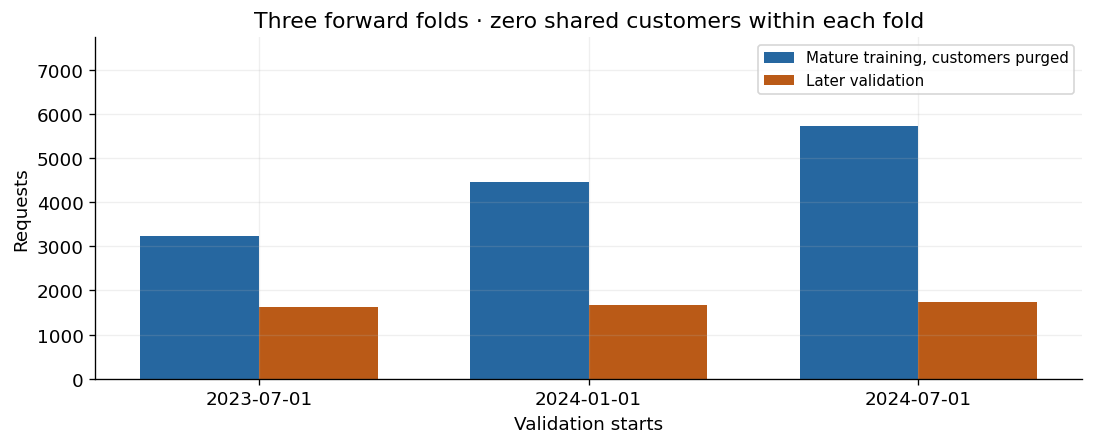

In [52]:
folds = make_time_group_split(clean, horizon_days=contract["target"]["horizon_days"])
fold_audit = pd.DataFrame([fold["audit"] for fold in folds])
for fold in folds:
    tr, va = clean.loc[fold["train"]], clean.loc[fold["valid"]]
    assert not set(tr.customer_id) & set(va.customer_id)
    assert (pd.to_datetime(tr.application_date) + pd.Timedelta(days=90) <
            pd.Timestamp(fold["audit"]["validation_start"])).all()
fold_audit["validation_positive_rate"] = fold_audit.validation_positives / fold_audit.validation_rows
display(fold_audit)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
x = np.arange(len(fold_audit))
ax.bar(x - .18, fold_audit.train_rows, .36, label="Mature training, customers purged", color="#2667A0")
ax.bar(x + .18, fold_audit.validation_rows, .36, label="Later validation", color="#BA5A17")
ax.set(xticks=x, xticklabels=fold_audit.validation_start, ylabel="Requests", xlabel="Validation starts",
       title="Three forward folds · zero shared customers within each fold")
ax.set_ylim(0, fold_audit.train_rows.max() * 1.35)
ax.legend(fontsize=9)
fig.savefig(ARTIFACTS / "day2_fold_sizes.png", dpi=160)
plt.show()


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. Hyperparameter Search Before Outer Validation</h2>
<p>I selected hyperparameters once from a historical cohort whose labels had matured before the first outer-validation window. I excluded all customers appearing in any of the three outer-validation periods from the search cohort.</p>
<p>Within the reserved cohort, I used three forward folds with customer separation. Each fold included an inner stopping split: I learned preprocessing and trees from inner-fit rows, selected the tree count using inner-stop log loss, and then refitted the model on the full fold-training rows.</p>
<ul><li>I kept outer-validation rows separate from imputation, tree-count and hyperparameter selection.</li><li>I did not use future target values to define search parameters.</li><li>I documented the relatively small search cohort in the released data and the limited positive examples in some inner partitions.</li></ul>
<p>I treated the best search AP as a model-selection statistic, not an estimate of future outer performance.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. البحث عن المعاملات قبل التحقق الخارجي</h2>
<p>اخترت المعاملات مرة واحدة من مجموعة تاريخية نضجت أهدافها قبل أول فترة تحقق خارجي. واستبعدت من مجموعة البحث جميع العملاء الذين ظهروا في أي من فترات التحقق الخارجي الثلاث.</p>
<p>داخل المجموعة المحجوزة، استخدمت ثلاث طيات زمنية مع فصل العملاء. تضمنت كل طية تقسيمًا داخليًا للإيقاف: تعلمت المعالجة والأشجار من صفوف inner fit، واخترت عدد الأشجار باستخدام inner-stop log loss، ثم أعدت تدريب النموذج على صفوف تدريب الطية كاملة.</p>
<ul><li>أبقيت صفوف التحقق الخارجي منفصلة عن اختيار التعويض وعدد الأشجار والمعاملات.</li><li>لم أستخدم قيم الأهداف المستقبلية لتحديد معاملات البحث.</li><li>وثّقت صغر حجم مجموعة البحث نسبيًا في البيانات المنشورة وقلة الأمثلة الموجبة في بعض الأجزاء الداخلية.</li></ul>
<p>اعتبرت أفضل قيمة AP في البحث إحصائية لاختيار النموذج، وليست تقديرًا للأداء الخارجي المستقبلي.</p>
</td>
</tr>
</table>


In [53]:
pool = reserve_tuning_pool(clean, folds)
outer_ids = np.concatenate([fold["valid"] for fold in folds])
assert not set(pool.customer_id) & set(clean.loc[outer_ids, "customer_id"])
assert (pd.to_datetime(pool.application_date) + pd.Timedelta(days=90) < pd.Timestamp("2023-07-01")).all()
display(pd.DataFrame([{"search_rows": len(pool), "search_positives": int(pool[target].sum()),
    "search_positive_rate": pool[target].mean(), "latest_application": pool.application_date.max(),
    "outer_validation_rows": len(outer_ids)}]))

,search_rows,search_positives,search_positive_rate,latest_application,outer_validation_rows
0,1935,176,0.090956,2023-04-01,5039



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. Bounded Optuna Hyperparameter Search</h2>
<p>I used mean <strong>Average Precision (AP)</strong> across three internal forward folds as the optimization objective. I limited the search to <code>learning_rate</code>, <code>num_leaves</code> and <code>min_child_samples</code>.</p>
<ul><li>Seed: 211.</li><li>I limited the search to eight sequential trials.</li><li>I applied a 120-second cooperative search budget, which could finish slightly after the boundary.</li><li><code>COMPLETE</code>: all three fold scores were calculated.</li><li><code>PRUNED</code>: the trial stopped early.</li><li><code>FAIL</code>: the attempt did not produce a complete objective; partial values were not treated as a completed mean.</li></ul>
<p>I used only completed trials for live results. If no trial completed, the notebook provided a stored <code>EDUCATIONAL_EXAMPLE</code> for discussion only and reported <code>TUNING_REQUIRED</code>. The example was not included in live results or submission. A fresh free-CPU session was the intended retry option instead of purchasing compute.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. البحث المحدود عن المعاملات باستخدام Optuna</h2>
<p>استخدمت متوسط <strong>Average Precision (AP)</strong> عبر ثلاث طيات زمنية داخلية هدفًا للتحسين. وحصرت البحث في <code>learning_rate</code> و<code>num_leaves</code> و<code>min_child_samples</code>.</p>
<ul><li>البذرة: 211.</li><li>حددت البحث بثماني تجارب متتابعة.</li><li>طبّقت ميزانية بحث تعاونية قدرها 120 ثانية، وقد ينتهي التنفيذ بعد الحد بقليل.</li><li><code>COMPLETE</code>: اكتملت درجات الطيات الثلاث.</li><li><code>PRUNED</code>: توقفت التجربة مبكرًا.</li><li><code>FAIL</code>: لم تنتج المحاولة هدفًا مكتملًا، ولم أتعامل مع القيم الجزئية بوصفها متوسطًا مكتملًا.</li></ul>
<p>اعتمدت على التجارب المكتملة فقط في النتائج الفعلية. وفي حال عدم اكتمال أي تجربة، يتيح الدفتر مثالًا محفوظًا <code>EDUCATIONAL_EXAMPLE</code> للنقاش فقط ويعرض <code>TUNING_REQUIRED</code>. لم أدرج المثال ضمن النتائج الفعلية أو التسليم. وكانت إعادة المحاولة في جلسة CPU مجانية جديدة هي الخيار المحدد بدل شراء موارد حوسبة.</p>
</td>
</tr>
</table>


,status,completed_trials,attempted_trials,elapsed_seconds,stopping_reason,best_tuning_ap
0,COMPLETE,8,8,6.566436,TRIAL_LIMIT,0.333269


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2022-10-01,2023-01-01,703,381,52,42,351,99,0,2022-09-30
1,2,2023-01-01,2023-03-01,1070,271,83,27,373,91,0,2022-12-31
2,3,2023-03-01,2023-04-02,1355,130,118,15,389,61,0,2023-02-28


,trial,state,mean_ap,seconds,learning_rate,num_leaves,min_child_samples,fold_1_ap,fold_2_ap,fold_3_ap
0,0,COMPLETE,0.316524,2.896661,0.085161,15,10,0.319910,0.320935,0.308727
1,1,COMPLETE,0.333269,1.388733,0.085305,31,40,0.391154,0.349373,0.259279
2,2,COMPLETE,0.308752,0.918251,0.034906,31,40,0.404534,0.271448,0.250276
3,3,COMPLETE,0.320550,0.296253,0.040259,31,20,0.384913,0.316815,0.259923
4,4,COMPLETE,0.327798,0.228414,0.062862,15,40,0.403532,0.310814,0.269049
5,5,COMPLETE,0.319093,0.229939,0.037608,7,10,0.365309,0.299275,0.292694
6,6,COMPLETE,0.318537,0.263648,0.039240,15,40,0.414490,0.284021,0.257101
7,7,COMPLETE,0.319024,0.251785,0.062020,31,20,0.376677,0.322038,0.258357


Frozen search parameters: {'learning_rate': 0.08530488562858765, 'num_leaves': 31, 'min_child_samples': 40}


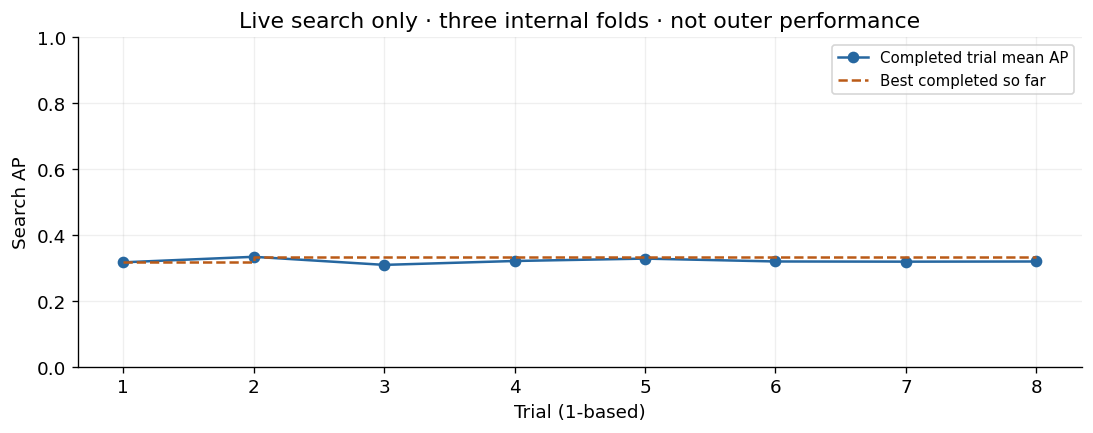

In [54]:
search, history = tune_on_reserved_pool(pool, contract, config)
has_tuned = search["best_params"] is not None
display(pd.DataFrame([{key: search[key] for key in ["status", "completed_trials", "attempted_trials",
    "elapsed_seconds", "stopping_reason", "best_tuning_ap"]}]))
display(pd.DataFrame(search["fold_audits"]))
display(history)
if not has_tuned:
    example = pd.read_csv(ROOT / "data/day2_optuna_example.csv")
    example_info = json.loads((ROOT / "data/day2_optuna_example.json").read_text(encoding="utf-8"))
    assert example_info["source"] == "EDUCATIONAL_EXAMPLE"
    print("EDUCATIONAL_EXAMPLE — discussion only; not your run or submission. TUNING_REQUIRED.")
    display(example)
else:
    print("Frozen search parameters:", search["best_params"])

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
completed = history[history.state.eq("COMPLETE")]
if len(completed):
    ax.plot(completed.trial + 1, completed.mean_ap, marker="o", color="#2667A0", label="Completed trial mean AP")
    ax.step(completed.trial + 1, completed.mean_ap.cummax(), where="post", color="#BA5A17",
            linestyle="--", label="Best completed so far")
    ax.legend(fontsize=9)
else:
    ax.text(.5, .5, "No completed live trials — rerun needed", transform=ax.transAxes, ha="center")
ax.set(xlabel="Trial (1-based)", ylabel="Search AP", ylim=(0, 1), xticks=range(1, config.trials+1),
       title="Live search only · three internal folds · not outer performance")
fig.savefig(ARTIFACTS / "day2_search.png", dpi=160)
plt.show()


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. Protocol Comparison After Freezing the Search</h2>
<p>I compared four protocols using LightGBM, with differences in the data protocol:</p>
<table><tr><th>Protocol</th><th>Purpose</th></tr><tr><td>Leaky random control</td><td>Deliberately used two post-outcome fields and all-row imputation; unsafe negative control</td></tr><tr><td>Clean random control</td><td>Used eligible fields and training-only imputation but still mixed time and customers; unsafe for decisions</td></tr><tr><td>Honest fixed</td><td>Used forward mature-label, customer-purged folds with fixed base parameters and 80 trees</td></tr><tr><td>Honest reserved search</td><td>Used the same honest outer folds with parameters frozen on the separate search cohort and internal tree selection</td></tr></table>
<p>The random protocols covered 10,000 requests, while the time-based protocols covered 5,039 later eligible requests with different training sizes. I interpreted the gaps descriptively, accounting for differences in periods, populations and data availability, rather than treating them as isolated causal estimates of leakage.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. مقارنة البروتوكولات بعد تثبيت البحث</h2>
<p>قارنت أربعة بروتوكولات باستخدام LightGBM، مع اختلاف بروتوكول البيانات:</p>
<table><tr><th>البروتوكول</th><th>الغرض</th></tr><tr><td>Leaky random control</td><td>استخدمت عمدًا خاصيتين بعد النتيجة وتعويضًا من كامل البيانات؛ ضابط سلبي غير آمن</td></tr><tr><td>Clean random control</td><td>استخدمت الخصائص المؤهلة وتعويض التدريب فقط، مع استمرار خلط الزمن والعملاء؛ غير صالح للقرارات</td></tr><tr><td>Honest fixed</td><td>استخدمت طيات زمنية ناضجة الأهداف ومستبعدة العملاء، مع الإعداد الأساسي الثابت و80 شجرة</td></tr><tr><td>Honest reserved search</td><td>استخدمت الطيات الخارجية الصادقة نفسها مع معاملات مجمدة من مجموعة بحث منفصلة واختيار داخلي لعدد الأشجار</td></tr></table>
<p>غطّت البروتوكولات العشوائية 10,000 طلب، بينما غطّت البروتوكولات الزمنية 5,039 طلبًا لاحقًا مؤهلًا بأحجام تدريب مختلفة. فسّرت الفروق وصفيًا مع مراعاة اختلاف الفترات والسكان والبيانات المتاحة، ولم أعتبرها تقديرات سببية مستقلة للتسرب.</p>
</td>
</tr>
</table>


In [55]:
controls = negative_controls(clean, dirty, contract, config)
fixed_report, fixed_oof, fixed_origin = evaluate_outer(
    clean, contract, folds, BASE_PARAMS, config, "clean_time_group_fixed", fixed_trees=80)
reports, predictions, origins = [controls, fixed_report], [fixed_oof], fixed_origin
if has_tuned:
    tuned_report, tuned_oof, tuned_origin = evaluate_outer(
        clean, contract, folds, search["best_params"], config, "clean_time_group_tuned")
    reports.append(tuned_report); predictions.append(tuned_oof); origins += tuned_origin
validation_report = pd.concat(reports, ignore_index=True)
summary = summarize_folds(validation_report)
oof = pd.concat(predictions, ignore_index=True)
assert not oof.duplicated(["scheme", "application_id"]).any()
display(summary.round(4))
display(validation_report[["scheme", "fold", "roc_auc", "average_precision", "train_rows",
    "validation_rows", "selected_trees", "shared_customers", "prediction_source"]].round(4))
gaps = summary.set_index("scheme")
print("Observed AP gap, leaky minus clean random:",
      round(gaps.loc["leaky_random_control", "ap_mean"] - gaps.loc["clean_random_control", "ap_mean"], 4))
print("Observed AP gap, clean random minus honest fixed:",
      round(gaps.loc["clean_random_control", "ap_mean"] - gaps.loc["clean_time_group_fixed", "ap_mean"], 4))

,scheme,folds,validation_rows,roc_auc_mean,roc_auc_sd,ap_mean,ap_sd
0,leaky_random_control,3,10000,0.9999,0.0002,0.9988,0.0014
1,clean_random_control,3,10000,0.8010,0.0200,0.3110,0.0293
2,clean_time_group_fixed,3,5039,0.7976,0.0206,0.3153,0.0426
3,clean_time_group_tuned,3,5039,0.7855,0.0232,0.3133,0.0259


,scheme,fold,roc_auc,average_precision,train_rows,validation_rows,selected_trees,shared_customers,prediction_source
0,leaky_random_control,1,0.9996,0.9973,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
1,clean_random_control,1,0.7807,0.2776,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
2,leaky_random_control,2,0.9999,0.9992,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
3,clean_random_control,2,0.8018,0.3232,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
4,leaky_random_control,3,1.0000,1.0000,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
5,clean_random_control,3,0.8206,0.3321,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
6,clean_time_group_fixed,1,0.7948,0.3395,3223,1632,80,0,LIVE_OUT_OF_FOLD
7,clean_time_group_fixed,2,0.8194,0.3403,4460,1674,80,0,LIVE_OUT_OF_FOLD
8,clean_time_group_fixed,3,0.7786,0.2661,5731,1733,80,0,LIVE_OUT_OF_FOLD
9,clean_time_group_tuned,1,0.7826,0.3356,3223,1632,24,0,LIVE_OUT_OF_FOLD


Observed AP gap, leaky minus clean random: 0.6879
Observed AP gap, clean random minus honest fixed: -0.0044



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Mean and Variation Analysis</h2>
<p>I reported the unweighted mean across three folds and used error bars to represent the sample standard deviation with <code>ddof=1</code>.</p>
<ul><li>I treated the folds as related time periods, not three independent experiments.</li><li>I did not interpret the error bars as confidence intervals or significance tests.</li><li>I used <strong>Average Precision</strong> for AP, not trapezoidal area under the precision–recall curve.</li><li>I examined fold size, positive rate and coverage alongside the headline metrics.</li></ul>
<p>I accounted for possible differences in selected tree counts or final decimal places across systems, even with pinned versions. I did not repeat the search based on disappointing outer-validation results, as repeated selection on outer folds would turn them into development data.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>تحليل المتوسط والتشتت</h2>
<p>عرضت المتوسط غير الموزون عبر ثلاث طيات، واستخدمت أشرطة الخطأ لتمثيل الانحراف المعياري العيّني باستخدام <code>ddof=1</code>.</p>
<ul><li>تعاملت مع الطيات بوصفها فترات زمنية مترابطة، وليست ثلاث تجارب مستقلة.</li><li>لم أفسّر أشرطة الخطأ على أنها فترات ثقة أو اختبارات دلالة إحصائية.</li><li>استخدمت <strong>Average Precision</strong> للدلالة على AP، وليس المساحة شبه المنحرفة تحت منحنى precision–recall.</li><li>فحصت حجم الطية ونسبة الفئة الموجبة والتغطية إلى جانب مقاييس الأداء الرئيسية.</li></ul>
<p>أخذت في الاعتبار احتمال اختلاف عدد الأشجار المختار أو آخر المنازل العشرية بين الأنظمة رغم تثبيت الإصدارات. ولم أكرر البحث بسبب نتائج تحقق خارجي أقل من المتوقع، لأن الاختيار المتكرر باستخدام الطيات الخارجية يحوّلها إلى بيانات تطوير.</p>
</td>
</tr>
</table>


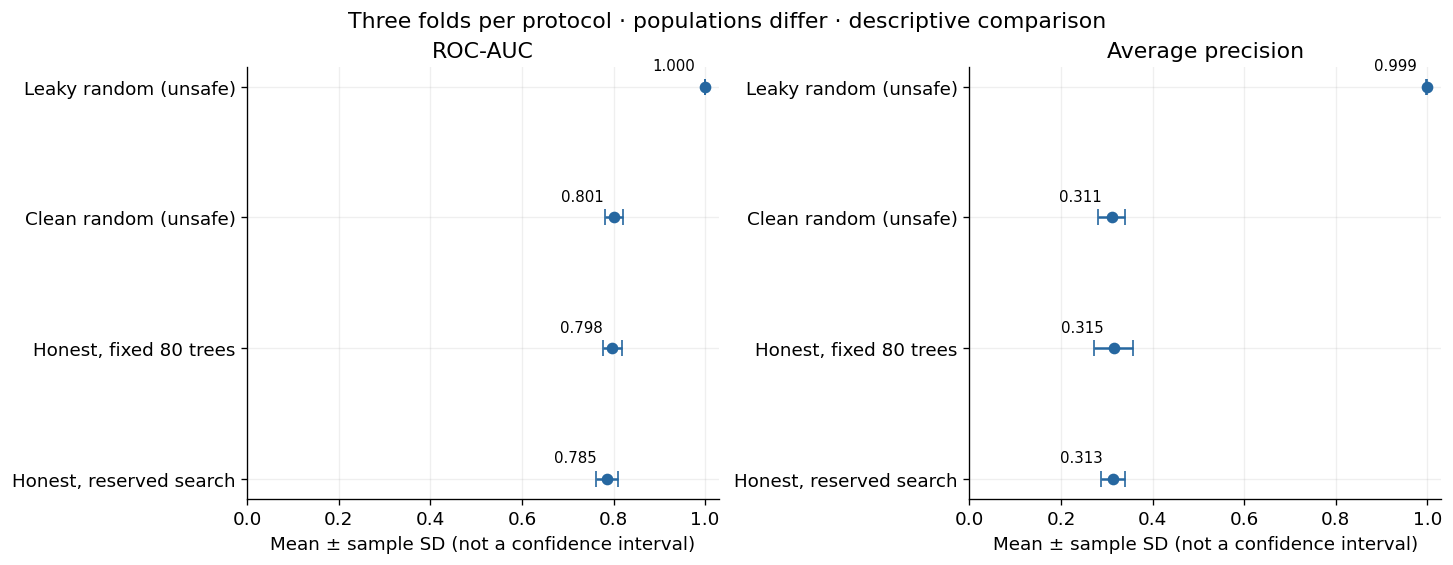

In [56]:
labels = {"leaky_random_control": "Leaky random (unsafe)", "clean_random_control": "Clean random (unsafe)",
          "clean_time_group_fixed": "Honest, fixed 80 trees", "clean_time_group_tuned": "Honest, reserved search"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
y = np.arange(len(summary))
for ax, mean_col, sd_col, title in zip(axes, ["roc_auc_mean", "ap_mean"], ["roc_auc_sd", "ap_sd"], ["ROC-AUC", "Average precision"]):
    ax.errorbar(summary[mean_col], y, xerr=summary[sd_col], fmt="o", capsize=5, color="#2667A0")
    ax.set(yticks=y, yticklabels=[labels[s] for s in summary.scheme], xlim=(0, 1.03),
           xlabel="Mean ± sample SD (not a confidence interval)", title=title)
    ax.invert_yaxis()
    for row, value in enumerate(summary[mean_col]):
        ax.annotate(f"{value:.3f}", (value, row), xytext=(-6, 10), textcoords="offset points", ha="right", fontsize=9)
fig.suptitle("Three folds per protocol · populations differ · descriptive comparison")
fig.savefig(ARTIFACTS / "day2_validation_comparison.png", dpi=160)
plt.show()


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. Out-of-Fold Coverage Verification</h2>
<p>I verified that every saved probability was generated for an application outside the corresponding fold's training rows after its internal choices were fixed.</p>
<ul><li>Each successful honest scheme produced 5,039 OOF probabilities.</li><li>The remaining 4,961 applications were retained as warm-up rows without OOF predictions.</li><li>Coverage reached 50.39% of all clean training rows and 100% of requests eligible from 2023-07-01 onward.</li><li>I did not fill warm-up rows with training predictions or artificial probabilities.</li><li>I did not export leaky-control predictions for later decision work.</li></ul>
<p>I treated the OOF set as development evidence rather than an independent final test or a guarantee of fairness or calibration. I preserved each row's role so later decisions could use the declared coverage.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. التحقق من تغطية OOF</h2>
<p>تحققت من أن كل احتمال محفوظ أُنتج لطلب خارج صفوف تدريب الطية المقابلة بعد تثبيت خياراتها الداخلية.</p>
<ul><li>أنتج كل إعداد صادق ناجح 5,039 احتمال OOF.</li><li>أبقيت الطلبات المتبقية البالغ عددها 4,961 صفوفًا تمهيدية دون تنبؤات OOF.</li><li>بلغت التغطية 50.39% من جميع صفوف التدريب النظيفة و100% من الطلبات المؤهلة بدءًا من 2023-07-01.</li><li>لم أملأ صفوف التمهيد بتنبؤات التدريب أو احتمالات مصطنعة.</li><li>لم أصدّر تنبؤات الضابط المتسرب لاستخدامها في أعمال القرار اللاحقة.</li></ul>
<p>تعاملت مع مجموعة OOF بوصفها دليلًا من مرحلة التطوير، وليست اختبارًا نهائيًا مستقلًا أو ضمانًا للعدالة أو المعايرة. واحتفظت بدور كل صف حتى تستند القرارات اللاحقة إلى التغطية المعلنة.</p>
</td>
</tr>
</table>


In [57]:
coverage = clean[["application_id", "application_date"]].copy()
coverage["role"], coverage["fold"] = "warmup_no_oof", 0
for fold in folds:
    coverage.loc[fold["valid"], "role"] = "eligible_oof"
    coverage.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
eligible_ids = set(coverage.loc[coverage.role.eq("eligible_oof"), "application_id"])
for scheme, group in oof.groupby("scheme"):
    assert set(group.application_id) == eligible_ids
    assert group.probability.between(0, 1).all()
display(pd.DataFrame([{"all_rows": len(clean), "eligible_rows": len(eligible_ids),
    "warmup_without_oof": len(clean)-len(eligible_ids), "whole_data_coverage": len(eligible_ids)/len(clean),
    "eligible_coverage": 1.0, "live_honest_schemes": oof.scheme.nunique()}]))

,all_rows,eligible_rows,warmup_without_oof,whole_data_coverage,eligible_coverage,live_honest_schemes
0,10000,5039,4961,0.5039,1.0,2


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. Write your own validation argument</h2>
<p>Complete the shared response dictionary in your own words, then rerun the response and export cells:</p>
<ol><li>Name one leaked field and explain why its information was unavailable at application time.</li><li>Justify time ordering, customer separation and the strict 90-day maturity rule.</li><li>Cite two numerical gaps from your validation table and explain why they do not prove universal superiority.</li><li>Explain why imputation is learned inside training and what the inner stopping set controls.</li><li>State one search-budget limitation and one OOF-coverage or fold-dependence limitation.</li></ol>
<p>The checkpoint detects missing fields only. It does not write your answer, judge correctness, award a grade or prove authorship.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. اكتب حجتك الخاصة للتحقق</h2>
<p>أكمل قاموس الإجابات المشترك بصياغتك أنت، ثم أعد تشغيل خلية الإجابات وخلية التصدير:</p>
<ol><li>اذكر خاصية متسربة، واشرح لماذا لم تكن معلومتها متاحة وقت تقديم الطلب.</li><li>برر ترتيب الزمن وفصل العملاء وقاعدة نضج الهدف الصارمة لمدة 90 يومًا.</li><li>استشهد بفجوتين رقميتين من جدول التحقق، واشرح لماذا لا تثبتان تفوقًا عامًا.</li><li>اشرح لماذا يُتعلم التعويض داخل التدريب وما الذي يتحكم فيه جزء الإيقاف الداخلي.</li><li>اذكر قيدًا في ميزانية البحث وقيدًا في تغطية OOF أو اعتماد الطيات.</li></ol>
<p>يفحص الحارس اكتمال الخانات فقط؛ لا يكتب إجابتك، ولا يحكم على صحتها، ولا يمنح درجة، ولا يثبت الملكية.</p>
</td>
</tr>
</table>

In [58]:
responses = {
    "leak_example": (
        "One leaked field is days_past_due_60. It is recorded after the application, "
        "so this information would not have been available at application time when "
        "the prediction or decision was made."
    ),

    "split_reason": (
        "Time ordering ensures that the model is trained on earlier applications and "
        "validated on later applications, which better reflects real deployment. "
        "Customer separation prevents the same customer from appearing in both training "
        "and validation, avoiding customer leakage. The strict 90-day maturity rule "
        "ensures that the default_within_90d outcome is fully observed before a record "
        "is eligible for training."
    ),

    "observed_gap": (
        "The observed AP gap between the leaky random control and the clean random "
        "control was 0.6879, showing that leakage can strongly inflate apparent model "
        "performance. The AP gap between the clean random control and the honest fixed "
        "protocol was -0.0044, showing that changing the validation protocol can affect "
        "the measured performance. These gaps are descriptive results from this dataset "
        "and these folds, so they do not prove that one protocol or model will be "
        "universally superior on future data."
    ),

    "imputer_reason": (
        "Imputation is learned only from the training data so that information from "
        "the validation data does not leak into preprocessing. The inner stopping set "
        "controls early stopping, determining when boosting should stop without using "
        "the outer validation set to make training decisions."
    ),

    "limitations": (
        "The search budget was limited to 8 completed trials, so the search may not "
        "have explored the best possible hyperparameter combination. In addition, OOF "
        "predictions covered only 5,039 of 10,000 rows (50.39%), while 4,961 rows were "
        "warm-up rows without OOF predictions. Therefore, the OOF results do not cover "
        "the entire dataset and are also dependent on the three forward folds used."
    )
}

checkpoint = reflection_check(responses)
print(checkpoint["status"])
print("Missing:", checkpoint["missing"])

READY_FOR_REVIEW
Missing: []



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. Evidence Export and Provenance Documentation</h2>
<p>I executed the export cell, which generated the validation tables, search record, audits, OOF predictions and coverage, provenance, reflection, run metadata, three figures and <code>environment.json</code>, then created <code>day2_artifacts.zip</code>.</p>
<p>I downloaded the ZIP from <strong>Files → tamweel → artifacts</strong>, extracted it and uploaded the actual files to my GitHub repository's <code>artifacts/</code> directory. I saved the executed notebook as <code>notebooks/02_validation_tuning.ipynb</code>.</p>
<ul><li><code>TECHNICAL_READY</code>: execution and at least one live tuning trial completed.</li><li><code>TUNING_REQUIRED</code>: no live trial completed; a rerun was required.</li><li><code>LEARNER_WORK_REQUIRED</code>: technical work existed, but written fields were incomplete.</li><li><code>READY_FOR_REVIEW</code>: required fields were present; this status did not represent a grade or correctness guarantee.</li></ul>
<p>I accounted for the fact that saving again replaces this day's artifact names and preserved a copy before rerunning. I ensured that no credentials, access tokens or personal data were uploaded.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. تصدير الأدلة وتوثيق مصادرها</h2>
<p>شغّلت خلية التصدير التي أنشأت جداول التحقق وسجل البحث والتدقيقات وتنبؤات OOF وتغطيتها ومصدر التدريب والتفسير وبيانات التشغيل وثلاثة رسوم و<code>environment.json</code>، ثم أنشأت <code>day2_artifacts.zip</code>.</p>
<p>نزّلت الحزمة من <strong>Files → tamweel → artifacts</strong>، وفككت ضغطها، ثم رفعت الملفات الفعلية إلى مجلد <code>artifacts/</code> في مستودعي على GitHub. وحفظت الدفتر المنفذ باسم <code>notebooks/02_validation_tuning.ipynb</code>.</p>
<ul><li><code>TECHNICAL_READY</code>: نجح التنفيذ واكتملت تجربة ضبط فعلية واحدة على الأقل.</li><li><code>TUNING_REQUIRED</code>: لم تكتمل أي تجربة فعلية؛ وكانت إعادة التشغيل مطلوبة.</li><li><code>LEARNER_WORK_REQUIRED</code>: توفرت الأدلة التقنية، لكن الحقول الكتابية كانت غير مكتملة.</li><li><code>READY_FOR_REVIEW</code>: كانت الحقول المطلوبة موجودة؛ ولم تمثل هذه الحالة درجة أو ضمانًا لصحة التفسير.</li></ul>
<p>أخذت في الاعتبار أن الحفظ المتكرر يستبدل أسماء ملفات هذا اليوم، واحتفظت بنسخة قبل إعادة التشغيل. وتأكدت من عدم رفع بيانات الاعتماد أو رموز الوصول أو البيانات الشخصية.</p>
</td>
</tr>
</table>


In [59]:
checkpoint = reflection_check(responses)
technical_status = "TECHNICAL_READY" if has_tuned else "TUNING_REQUIRED"
csv_outputs = {"validation_report.csv": validation_report, "validation_summary.csv": summary,
    "optuna_results.csv": history, "leakage_audit.csv": audit, "fold_audit.csv": fold_audit,
    "day2_oof_predictions.csv": oof, "day2_oof_coverage.csv": coverage}
for filename, table in csv_outputs.items():
    table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "data_manifest_sha256": MANIFEST_SHA256,
    "dirty_data_sha256": hashlib.sha256((ROOT / "data/tamweel_dirty.csv").read_bytes()).hexdigest(),
    "config": asdict(config), "mode": "FAST" if FAST_MODE else "FULL", "python": platform.python_version(),
    "duplicates": duplicates, "removed_features": leaked_features,
    "oof_rows_per_scheme": {name: len(group) for name, group in oof.groupby("scheme")},
    "oof_whole_data_coverage": len(eligible_ids)/len(clean), "warmup_rows": len(clean)-len(eligible_ids),
    "search_source": "LIVE", "example_used_for_results": False,
    "challenge_used_for_modeling": False, "grading": "No automatic grade"}
json_outputs = {"best_params.json": search, "day2_provenance.json": origins,
                "day2_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day2_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
files = list(csv_outputs) + list(json_outputs) + ["day2_fold_sizes.png", "day2_search.png",
    "day2_validation_comparison.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day2_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for filename in files:
        assert (ARTIFACTS / filename).is_file(), filename
        archive.write(ARTIFACTS / filename, arcname=filename)
print(technical_status, "|", checkpoint["status"])
print(f"Saved {len(files)} files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك")

TECHNICAL_READY | READY_FOR_REVIEW
Saved 15 files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Completion checkpoint and next step</h2>
<ul><li>You can identify the removed post-outcome fields and explain their availability time.</li><li>Each fold shows zero shared customers and mature training labels before validation starts.</li><li>You can distinguish attempted, completed, pruned and failed search trials.</li><li>You read fold means, sample standard deviations, population differences and OOF coverage together.</li><li>You completed the five learner-owned responses and saved the executed notebook plus the artifact bundle outside the temporary session.</li></ul>
<p><strong>Before presenting results:</strong> show one leakage example, point to evidence of customer separation and label maturity, distinguish mean fold AP from pooled AP, and state the result's limits beside the score.</p>
<p><strong>References:</strong> scikit-learn cross-validation and preprocessing-leakage guidance, LightGBM early stopping and Optuna bounded-study documentation linked in the course guide.</p>
<p><strong>Day 3:</strong> use the honest validation foundation to examine simulated decision costs, thresholds and the consequences of false approvals and false declines.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>نقطة الإكمال والخطوة التالية</h2>
<ul><li>تستطيع تحديد خصائص ما بعد النتيجة المحذوفة وشرح زمن إتاحة معلوماتها.</li><li>تُظهر كل طية صفر عملاء مشتركين ونضج أهداف التدريب قبل بدء التحقق.</li><li>تستطيع التمييز بين محاولات البحث والمكتمل منها والموقوفة والفاشلة.</li><li>تقرأ متوسطات الطيات والانحرافات المعيارية العيّنية واختلاف السكان وتغطية OOF معًا.</li><li>أكملت الإجابات الخمس التي يملكها المتدرب، وحفظت الدفتر المنفذ وحزمة الأدلة خارج الجلسة المؤقتة.</li></ul>
<p><strong>قبل عرض النتائج:</strong> اعرض مثالًا للتسرب، وأشر إلى دليل فصل العملاء ونضج الهدف، وميّز بين متوسط AP عبر الطيات وAP بعد جمع الاحتمالات، وضع حدود النتيجة بجانب الدرجة.</p>
<p><strong>المراجع:</strong> إرشادات scikit-learn للتحقق ومنع تسرب المعالجة، وتوثيق LightGBM للإيقاف المبكر، وتوثيق Optuna للبحث المحدود، وكلها مرتبطة في دليل الدورة.</p>
<p><strong>اليوم الثالث:</strong> استخدم أساس التحقق الصادق لفحص تكاليف القرار التعليمية والعتبات وآثار الموافقات الخاطئة والرفض الخاطئ.</p>
</td>
</tr>
</table>

# **Threshold & capacity | العتبة والسعة**


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. Controlled Environment Preparation</h2>
<p>I opened a fresh session, selected the free CPU runtime and executed <strong>Runtime → Run all</strong>. The setup verified pinned versions, data hashes and support files before training.</p>
<ul><li><code>FAST_MODE=True</code>: I used 80 trees per model and two CPU threads as the initial configuration.</li><li><code>FULL_MODE=True</code>: I kept the optional 160-tree cap available.</li><li>I rebuilt the Day 2 time/customer split from the source without requiring any previous notebook output.</li><li>I did not require a GPU, API key, Drive mount, paid package or external service.</li></ul>
<p>I froze the tree count before comparing imbalance treatments and did not retune after examining the day's OOF results. If the setup requested a restart, I restarted the session and reran the notebook from the beginning.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. إعداد بيئة تشغيل محكومة</h2>
<p>فتحت جلسة جديدة، واخترت CPU المجاني، ثم نفّذت <strong>Runtime → Run all</strong>. تحقّق الإعداد من الإصدارات المثبتة وبصمات البيانات وملفات الدعم قبل التدريب.</p>
<ul><li><code>FAST_MODE=True</code>: استخدمت 80 شجرة لكل نموذج وخيطي CPU بوصفه الإعداد الأولي.</li><li><code>FULL_MODE=True</code>: أبقيت السقف الاختياري البالغ 160 شجرة متاحًا.</li><li>أعدت بناء تقسيم الزمن والعملاء من اليوم الثاني باستخدام البيانات المصدرية دون الحاجة إلى مخرجات دفتر سابق.</li><li>لم أحتج إلى GPU أو مفتاح API أو ربط Drive أو حزمة مدفوعة أو خدمة خارجية.</li></ul>
<p>ثبّتُّ عدد الأشجار قبل مقارنة طرق معالجة عدم التوازن، ولم أُعد ضبطه بعد فحص نتائج OOF لهذا اليوم. وإذا طلب الإعداد إعادة التشغيل، أعدت تشغيل الجلسة ونفّذت الدفتر من البداية.</p>
</td>
</tr>
</table>


In [60]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
DAY2_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
DAY2_SHA256 = "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"
fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{DAY2_REVISION}/scripts/day2_validation.py",
               ROOT / "scripts/day2_validation.py", DAY2_SHA256)
LAB_REVISION = "c2dc52e129878d0d487db1874891c658de7c4d0d"
SUPPORT_HASHES = {'scripts/day3_decision.py': '40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12', 'data/day3_oof_example.csv': '659952bef85ac3b7ceb7ab84eb2102de6c9b433a1ba122cd57df96581baf0eb3', 'data/day3_oof_example.json': '920cf9830043afcc83f8c276c8945677296eb3c49a6e69326d47f6080a9e7fad'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
                   ROOT / relative, digest)
print("Day 3 setup verified | إعداد اليوم الثالث جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 3 setup verified | إعداد اليوم الثالث جاهز



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. Teaching Loss and Capacity Policy Definition</h2>
<p>I defined the target as a default event within 90 days after application. I used entirely synthetic records and kept the challenge data closed.</p>
<table><tr><th>Outcome</th><th>Teaching meaning</th><th>Loss units</th></tr><tr><td>TP</td><td>Flag before a later default event</td><td>0</td></tr><tr><td>FN</td><td>Later default without a flag</td><td>10</td></tr><tr><td>FP</td><td>Flag on a non-default case</td><td>1</td></tr><tr><td>TN</td><td>Non-default case without a flag</td><td>0</td></tr></table>
<p><strong>Observed educational loss = 10 × FN + 1 × FP.</strong> I excluded review cost and review effectiveness from this simplified policy.</p>
<p><strong>Capacity rule:</strong> I limited flags to 12% of requests in <em>each</em> validation period, rounded down to a whole request. I did not rely on the pooled rate alone because it could hide overload in one period. I kept this policy fixed throughout the core exercise.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. تحديد سياسة الخسارة والسعة التعليمية</h2>
<p>حددت الهدف بأنه وقوع حدث تعثر خلال 90 يومًا بعد تقديم الطلب. استخدمت سجلات اصطناعية بالكامل وأبقيت بيانات التحدي مغلقة.</p>
<table><tr><th>النتيجة</th><th>معناها التعليمي</th><th>وحدات الخسارة</th></tr><tr><td>TP</td><td>إشارة قبل حدث تعثر لاحق</td><td>0</td></tr><tr><td>FN</td><td>تعثر لاحق لم تُرفع له إشارة</td><td>10</td></tr><tr><td>FP</td><td>إشارة لحالة لم تتعثر</td><td>1</td></tr><tr><td>TN</td><td>حالة سليمة بلا إشارة</td><td>0</td></tr></table>
<p><strong>الخسارة التعليمية المرصودة = 10 × FN + 1 × FP.</strong> استبعدت تكلفة المراجعة وفعاليتها من هذه السياسة المبسطة.</p>
<p><strong>قاعدة السعة:</strong> حددت الإشارات بحيث لا تتجاوز 12% من طلبات <em>كل</em> فترة تحقق، مع التقريب إلى العدد الصحيح الأدنى. لم أعتمد على النسبة المجمعة وحدها لأنها قد تخفي ازدحامًا في إحدى الفترات. وأبقيت هذه السياسة ثابتة طوال التطبيق الأساسي.</p>
</td>
</tr>
</table>


In [61]:
import json, platform, zipfile
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications, make_time_group_split
from day3_decision import (STRATEGIES, TARGET, DecisionConfig, CostPolicy, generate_oof,
    validate_oof, threshold_sweep, select_threshold, flag_at, period_audit, region_audit,
    reflection_check, load_example, TrainingBudgetExpired)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = DecisionConfig(trees=80 if FAST_MODE else 160)
policy = CostPolicy(**contract["decision_policy"])
MODEL_FOR_DECISION = "weighted"  # Declared before comparison; not a claim of superiority.
USE_EXAMPLE = False  # True is discussion only, never your submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
assert MODEL_FOR_DECISION in STRATEGIES
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
folds = make_time_group_split(train, horizon_days=contract["target"]["horizon_days"])
display(pd.DataFrame([{"training_rows": len(train), "positive_rate": train[TARGET].mean(),
    "FN_loss_units": policy.false_negative_cost, "FP_loss_units": policy.false_positive_cost,
    "period_capacity_fraction": policy.max_flag_fraction, "trees_per_model": config.trees}]))
display(pd.DataFrame([fold["audit"] for fold in folds]))

,training_rows,positive_rate,FN_loss_units,FP_loss_units,period_capacity_fraction,trees_per_model
0,10000,0.0789,10,1,0.12,80


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. Training-Only Changes Without Modifying Validation</h2>
<p>I applied three LightGBM strategies using the same approved features, folds, tree budget and random seed:</p>
<table><tr><th>Strategy</th><th>Training change</th></tr><tr><td><code>unweighted</code></td><td>I used no row duplication or class weight</td></tr><tr><td><code>weighted</code></td><td>I calculated <code>scale_pos_weight = negatives / positives</code> from each fold's training rows only</td></tr><tr><td><code>oversampled</code></td><td>I randomly duplicated the minority class within training until the classes were balanced</td></tr></table>
<p>I learned missing-value imputation from the original training rows before oversampling and kept validation prevalence unchanged. I distinguished class weighting, which changes model fitting, from the FN/FP policy, which changes the downstream decision, as they are not the same quantity.</p>
<p>I accounted for the possibility that weighting and oversampling could distort probability calibration. I did not interpret a raw score of 0.70 as a reliable 70% probability before the Day 4 calibration checks.</p>
<p>If the cooperative CPU budget expired, a labelled educational example could support discussion, but I did not treat it as my own run or a valid submission. Assessment mode disabled this fallback.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. تعديل التدريب فقط دون تغيير بيانات التحقق</h2>
<p>طبّقت ثلاث استراتيجيات باستخدام LightGBM مع الحفاظ على الخصائص والطيات وميزانية الأشجار والبذرة العشوائية نفسها:</p>
<table><tr><th>الاستراتيجية</th><th>التغيير داخل التدريب</th></tr><tr><td><code>unweighted</code></td><td>لم أستخدم نسخ الصفوف أو أوزان الفئات</td></tr><tr><td><code>weighted</code></td><td>حسبت <code>scale_pos_weight = negatives / positives</code> من صفوف تدريب كل طية فقط</td></tr><tr><td><code>oversampled</code></td><td>نسخت عينات الفئة الأقل عشوائيًا داخل التدريب حتى توازنت الفئتان</td></tr></table>
<p>تعلمت تعويض القيم المفقودة من صفوف التدريب الأصلية قبل إعادة العينات، وأبقيت نسبة الفئة الموجبة في التحقق دون تغيير. وميّزت بين وزن الفئات الذي يغيّر تدريب النموذج وسياسة FN/FP التي تغيّر القرار اللاحق، لأنهما ليسا الكمية نفسها.</p>
<p>أخذت في الاعتبار أن وزن الفئات وإعادة العينات قد يشوّهان معايرة الاحتمالات. ولم أفسّر الدرجة الخام 0.70 بوصفها احتمالًا موثوقًا قدره 70% قبل إجراء فحوص المعايرة في اليوم الرابع.</p>
<p>إذا انتهت ميزانية CPU التعاونية، فقد يُستخدم مثال تعليمي موسوم للنقاش، لكنني لم أتعامل معه بوصفه تشغيلًا نفّذته أو تسليمًا صالحًا. وكان وضع التقييم يعطّل هذا البديل.</p>
</td>
</tr>
</table>


In [62]:
fallback_reason = None
if not USE_EXAMPLE:
    try:
        oof, model_report, provenance = generate_oof(train, contract, config)
    except TrainingBudgetExpired as exc:
        if ASSESSMENT_MODE:
            raise
        USE_EXAMPLE, fallback_reason = True, str(exc)
if USE_EXAMPLE:
    oof, example_info = load_example(ROOT / "data/day3_oof_example.csv",
        ROOT / "data/day3_oof_example.json", train, folds, assessment_mode=ASSESSMENT_MODE)
    model_report = pd.DataFrame(example_info["model_report"])
    provenance = {"source": "EDUCATIONAL_EXAMPLE", "example_metadata": example_info,
                  "fallback_reason": fallback_reason or "Learner selected discussion example"}
SOURCE = oof.source.iloc[0]
effective_config = example_info["config"] if USE_EXAMPLE else asdict(config)
coverage = validate_oof(oof, train, folds)
print("LIVE — your CPU run" if SOURCE == "LIVE" else
      "EDUCATIONAL_EXAMPLE — discussion only; EXAMPLE_ONLY_NOT_SUBMITTABLE")
display(pd.DataFrame([coverage]))
display(model_report[["strategy", "fold", "original_training_rows", "fitted_rows",
    "scale_pos_weight", "training_positive_rate", "fitted_positive_rate", "average_precision",
    "train_seconds", "source"]].round(4))
selected = oof[oof.strategy.eq(MODEL_FOR_DECISION)].copy()
assert selected.application_id.is_unique
print(f"Decision strategy declared before comparison: {MODEL_FOR_DECISION}")

LIVE — your CPU run


,eligible_rows,all_rows,whole_data_coverage,eligible_coverage,warmup_without_oof,source
0,5039,10000,0.5039,1.0,4961,LIVE


,strategy,fold,original_training_rows,fitted_rows,scale_pos_weight,training_positive_rate,fitted_positive_rate,average_precision,train_seconds,source
0,unweighted,1,3223,3223,1.0000,0.0850,0.0850,0.3395,0.1297,LIVE
1,weighted,1,3223,3223,10.7628,0.0850,0.0850,0.3378,0.0955,LIVE
2,oversampled,1,3223,5898,1.0000,0.0850,0.5000,0.3502,0.1411,LIVE
3,unweighted,2,4460,4460,1.0000,0.0791,0.0791,0.3403,0.1083,LIVE
4,weighted,2,4460,4460,11.6346,0.0791,0.0791,0.3295,0.1119,LIVE
5,oversampled,2,4460,8214,1.0000,0.0791,0.5000,0.3390,0.1619,LIVE
6,unweighted,3,5731,5731,1.0000,0.0811,0.0811,0.2661,0.1211,LIVE
7,weighted,3,5731,5731,11.3247,0.0811,0.0811,0.2707,0.1551,LIVE
8,oversampled,3,5731,10532,1.0000,0.0811,0.5000,0.2776,0.1929,LIVE


Decision strategy declared before comparison: weighted



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. Accuracy Analysis and Its Limitations</h2>
<p>I evaluated all three strategies on the same 5,039 later eligible applications. I kept the remaining 4,961 warm-up rows without OOF predictions and did not fill them with training predictions.</p>
<ul><li><strong>ROC-AUC:</strong> I evaluated pooled OOF ranking quality across thresholds.</li><li><strong>Average Precision:</strong> I used the course PR-AUC definition for the pooled OOF rows.</li><li><strong>Accuracy at 0.5:</strong> I treated it as a decision result at one arbitrary threshold, not a complete model-quality measure.</li></ul>
<p>I examined the “flag nobody” reference, which could show high accuracy despite zero recall. I assessed prevalence, AP, recall, precision, flags and loss together. I also distinguished pooled AP from the mean of Day 2 fold AP values.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. تحليل Accuracy وحدود الاعتماد عليها</h2>
<p>قيّمت الاستراتيجيات الثلاث على الطلبات اللاحقة المؤهلة نفسها، وعددها 5,039 طلبًا. وأبقيت الصفوف التمهيدية المتبقية وعددها 4,961 دون تنبؤات OOF، ولم أملأها بتنبؤات التدريب.</p>
<ul><li><strong>ROC-AUC:</strong> قيّمت جودة ترتيب تنبؤات OOF المجمعة عبر العتبات.</li><li><strong>Average Precision:</strong> استخدمت تعريف PR-AUC المعتمد في الدورة لصفوف OOF المجمعة.</li><li><strong>Accuracy عند 0.5:</strong> تعاملت معها بوصفها نتيجة قرار عند عتبة اعتباطية واحدة، وليست مقياسًا شاملًا لجودة النموذج.</li></ul>
<p>فحصت مرجع «عدم رفع إشارة لأي طلب»، الذي قد يحقق Accuracy مرتفعة رغم أن Recall يساوي صفرًا. وقيّمت نسبة الفئة الموجبة وAP وRecall وPrecision وعدد الإشارات والخسارة معًا. وميّزت أيضًا بين AP المجمعة ومتوسط قيم AP لطيات اليوم الثاني.</p>
</td>
</tr>
</table>


,strategy,rows,positive_rate,pooled_roc_auc,pooled_ap,accuracy_at_0_5,recall_at_0_5,precision_at_0_5,flags_at_0_5,loss_at_0_5,capacity_ok_at_0_5,source
0,unweighted,5039,0.0762,0.7979,0.3091,0.9256,0.1250,0.5517,87,3399,True,LIVE
1,weighted,5039,0.0762,0.7969,0.3100,0.8125,0.5781,0.2209,1005,2403,False,LIVE
2,oversampled,5039,0.0762,0.7979,0.3159,0.8073,0.5990,0.2197,1047,2357,False,LIVE


,rule,rows,accuracy,recall,precision,loss_units
0,No flags for anyone,5039,0.923794,0.0,None,3840


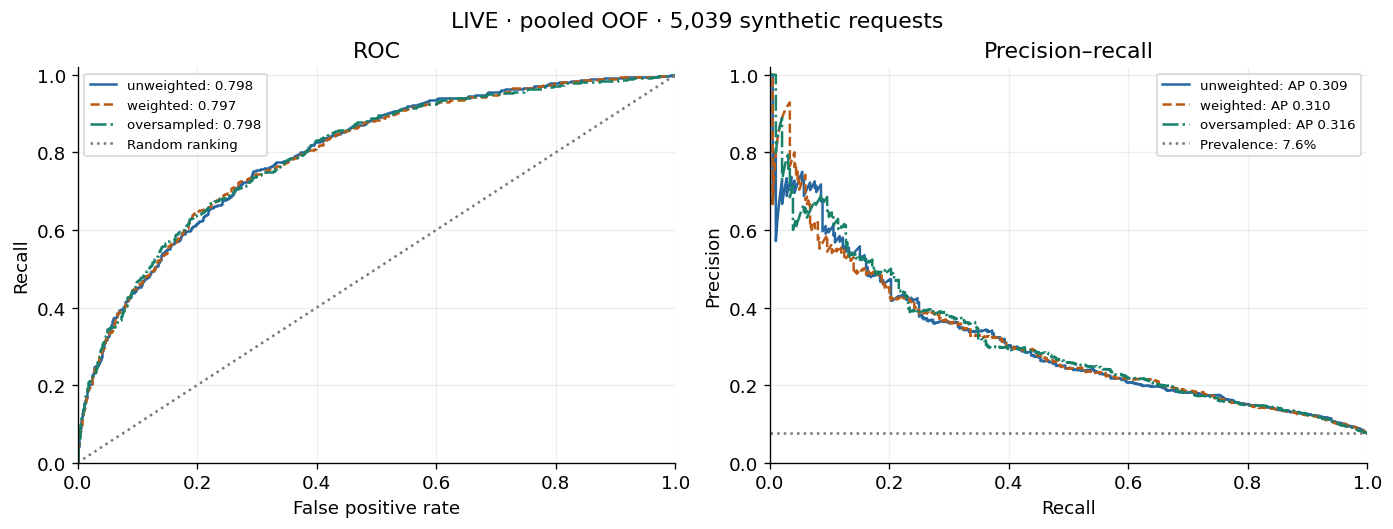

In [63]:
comparison_rows = []
for strategy, group in oof.groupby("strategy", sort=False):
    sweep = threshold_sweep(group, policy)
    default = sweep.loc[sweep.threshold.eq(.5)].iloc[0]
    comparison_rows.append({"strategy": strategy, "rows": len(group), "positive_rate": group[TARGET].mean(),
        "pooled_roc_auc": roc_auc_score(group[TARGET], group.probability),
        "pooled_ap": average_precision_score(group[TARGET], group.probability),
        "accuracy_at_0_5": default.accuracy, "recall_at_0_5": default.recall,
        "precision_at_0_5": default.precision, "flags_at_0_5": default.flagged,
        "loss_at_0_5": default.loss_units, "capacity_ok_at_0_5": default.capacity_feasible, "source": SOURCE})
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))
no_flag_reference = {"rule": "No flags for anyone", "rows": len(selected),
    "accuracy": 1-selected[TARGET].mean(), "recall": 0., "precision": None,
    "loss_units": int(selected[TARGET].sum()) * policy.false_negative_cost}
display(pd.DataFrame([no_flag_reference]))

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": .2})
colors = {"unweighted": "#2667A0", "weighted": "#BA5A17", "oversampled": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
for strategy, style in zip(STRATEGIES, ["-", "--", "-."]):
    group = oof[oof.strategy.eq(strategy)]
    fpr, tpr, _ = roc_curve(group[TARGET], group.probability)
    precision, recall, _ = precision_recall_curve(group[TARGET], group.probability)
    row = comparison.set_index("strategy").loc[strategy]
    axes[0].plot(fpr, tpr, color=colors[strategy], linestyle=style, label=f"{strategy}: {row.pooled_roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[strategy], linestyle=style, label=f"{strategy}: AP {row.pooled_ap:.3f}")
axes[0].plot([0,1], [0,1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(selected[TARGET].mean(), color="#777777", linestyle=":", label=f"Prevalence: {selected[TARGET].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="Recall")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
fig.suptitle(f"{SOURCE} · pooled OOF · {len(selected):,} synthetic requests")
fig.savefig(ARTIFACTS / "day3_roc_pr.png", dpi=160)
plt.show()


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. Decision Threshold Sweep and Selection</h2>
<p>I flagged requests when <strong>score ≥ threshold</strong>. I evaluated every distinct score, explicitly included 0.5 and added a no-flag rule, avoiding a coarse grid that could miss the best observed rule.</p>
<ul><li>I kept tied scores together and did not break ties by identifier to fill capacity.</li><li>When loss values tied, I preferred fewer flags and then the higher threshold.</li><li>I selected one minimum-loss rule without a capacity limit and another minimum-loss rule that was feasible in every period.</li></ul>
<p>I verified that the unconstrained rule could not have higher observed OOF loss than the 0.5 rule because 0.5 was included among the candidates. I also accounted for the possibility of higher loss under the capacity-constrained rule when 0.5 was infeasible.</p>
<p>I selected thresholds using OOF predictions rather than training predictions, while recognizing that the same development labels were still used for threshold selection. I treated the selected loss as optimistic development evidence, not final-test performance.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. فحص عتبات القرار واختيارها</h2>
<p>رفعت الإشارة للطلبات عندما كانت <strong>الدرجة ≥ العتبة</strong>. فحصت كل درجة مميزة، وأدرجت 0.5 صراحة، وأضفت قاعدة دون إشارات، لتجنب استخدام شبكة خشنة قد تفوّت أفضل قاعدة مرصودة.</p>
<ul><li>أبقيت الدرجات المتعادلة معًا، ولم أكسر التعادل باستخدام المعرّف لملء السعة.</li><li>عند تساوي قيم الخسارة، فضّلت عددًا أقل من الإشارات، ثم العتبة الأعلى.</li><li>اخترت قاعدة تحقق أقل خسارة دون قيد على السعة، وقاعدة أخرى تحقق أقل خسارة مع الالتزام بالسعة في كل فترة.</li></ul>
<p>تحققت من أن القاعدة غير المقيدة لا يمكن أن تحقق خسارة OOF مرصودة أعلى من قاعدة 0.5، لأن 0.5 كانت ضمن العتبات المرشحة. وأخذت في الاعتبار احتمال ارتفاع الخسارة مع القاعدة المقيدة بالسعة عندما تكون عتبة 0.5 غير قابلة للتنفيذ.</p>
<p>اخترت العتبات باستخدام تنبؤات OOF بدلًا من تنبؤات التدريب، مع إدراكي أن أهداف التطوير نفسها استُخدمت لاختيار العتبة. وتعاملت مع الخسارة المختارة بوصفها دليلًا متفائلًا من مرحلة التطوير، وليست أداءً لاختبار نهائي.</p>
</td>
</tr>
</table>


,rule,threshold,tp,fp,fn,tn,recall,precision,flagged,flag_fraction,loss_units,loss_units_per_10000,capacity_feasible
0,Default 0.5,0.5000,222,783,162,3872,0.5781,0.2209,1005,0.1994,2403,4768.8033,False
1,"Minimum loss, no capacity limit",0.4486,246,895,138,3760,0.6406,0.2156,1141,0.2264,2275,4514.7847,False
2,"Minimum loss, every-period capacity",0.6583,157,369,227,4286,0.4089,0.2985,526,0.1044,2639,5237.1502,True


Constrained minus default loss: +236 educational units. Default feasible: False
Exact rule to preserve in JSON: 0.6583471436014694 with >=


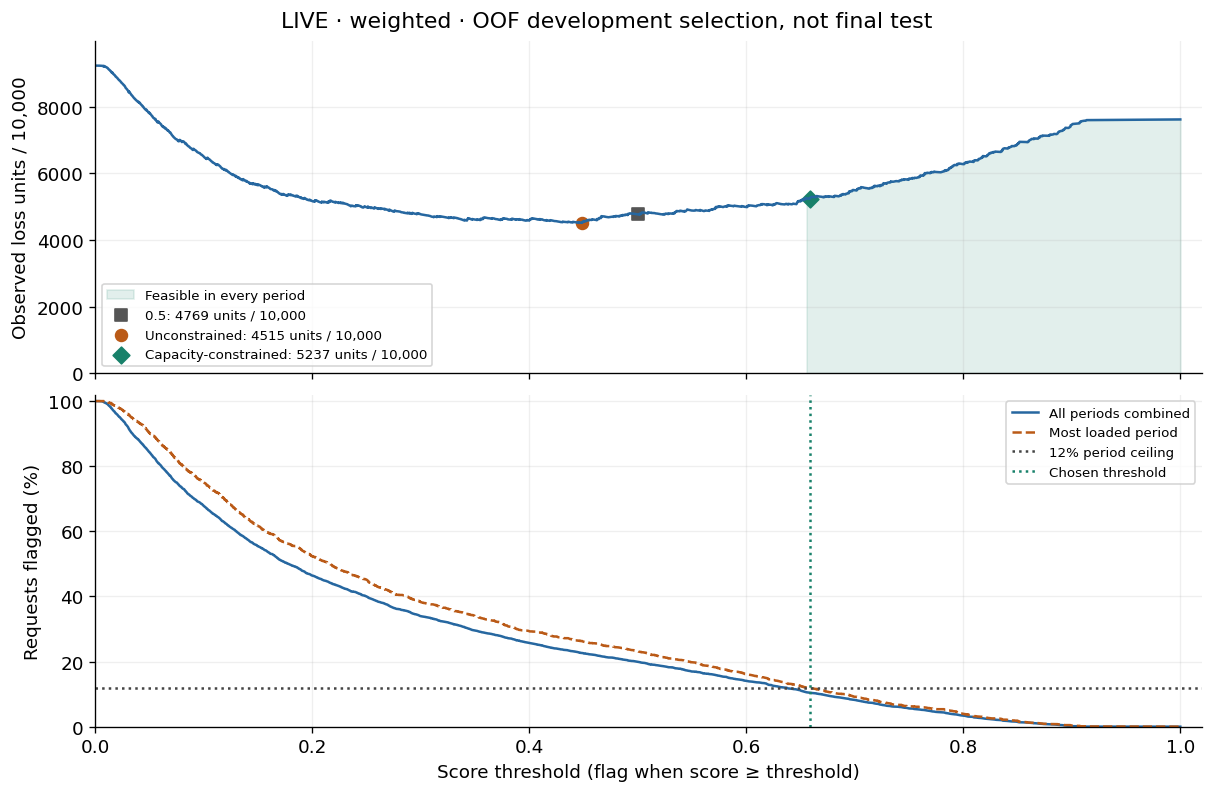

In [64]:
cost_curve = threshold_sweep(selected, policy)
unconstrained = select_threshold(cost_curve, constrained=False)
chosen = select_threshold(cost_curve, constrained=True)
default = cost_curve.loc[cost_curve.threshold.eq(.5)].iloc[0].to_dict()
operating_points = pd.DataFrame([{**point, "rule": name} for name, point in
    [("Default 0.5", default), ("Minimum loss, no capacity limit", unconstrained),
     ("Minimum loss, every-period capacity", chosen)]])
display(operating_points[["rule", "threshold", "tp", "fp", "fn", "tn", "recall", "precision",
    "flagged", "flag_fraction", "loss_units", "loss_units_per_10000", "capacity_feasible"]].round(4))
assert unconstrained["loss_units"] <= default["loss_units"]
if default["capacity_feasible"]:
    assert chosen["loss_units"] <= default["loss_units"]
periods = period_audit(selected, chosen["threshold"], policy)
assert periods.within_capacity.all()
delta = chosen["loss_units"] - default["loss_units"]
print(f"Constrained minus default loss: {delta:+.0f} educational units. Default feasible: {default['capacity_feasible']}")
print("Exact rule to preserve in JSON:", repr(chosen["threshold"]), "with >=")

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(cost_curve.threshold, cost_curve.loss_units_per_10000, color="#2667A0")
axes[0].fill_between(cost_curve.threshold, 0, cost_curve.loss_units_per_10000,
    where=cost_curve.capacity_feasible, color="#18816A", alpha=.12, label="Feasible in every period")
for label, point, marker, color in [("0.5", default, "s", "#555555"),
    ("Unconstrained", unconstrained, "o", "#BA5A17"), ("Capacity-constrained", chosen, "D", "#18816A")]:
    axes[0].scatter([point["threshold"]], [point["loss_units_per_10000"]], marker=marker, color=color, s=50,
        label=f"{label}: {point['loss_units_per_10000']:.0f} units / 10,000")
axes[0].set(ylabel="Observed loss units / 10,000", ylim=(0, cost_curve.loss_units_per_10000.max()*1.08))
axes[0].legend(fontsize=8)
axes[1].plot(cost_curve.threshold, cost_curve.flag_fraction*100, label="All periods combined", color="#2667A0")
axes[1].plot(cost_curve.threshold, cost_curve.max_period_flag_fraction*100, linestyle="--",
    label="Most loaded period", color="#BA5A17")
axes[1].axhline(policy.max_flag_fraction*100, color="#444444", linestyle=":", label="12% period ceiling")
axes[1].axvline(chosen["threshold"], color="#18816A", linestyle=":", label="Chosen threshold")
axes[1].set(xlabel="Score threshold (flag when score ≥ threshold)", ylabel="Requests flagged (%)", ylim=(0,102), xlim=(0,1.02))
axes[1].legend(fontsize=8)
fig.suptitle(f"{SOURCE} · {MODEL_FOR_DECISION} · OOF development selection, not final test")
fig.savefig(ARTIFACTS / "cost_curve.png", dpi=160)
plt.show()


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. Per-Period Capacity Audit and Policy Sensitivity Analysis</h2>
<p>I used the per-period table as the binding evidence for capacity compliance rather than relying on the pooled rate alone. I preserved the full precision of the exported threshold because rounding could change which tied or boundary scores were flagged.</p>
<p>I tested FN costs of 8, 10 and 12 while keeping FP cost at 1 and capacity at 12%. I treated these as ±20% policy scenarios, not confidence intervals, to examine whether the operating point was sensitive to a plausible change in assumptions.</p>
<p>I recognized that the theoretical unconstrained threshold of 1/11 required calibrated probabilities, the stated loss matrix and no capacity limit. I did not impose it on the day's weighted raw scores.</p>
<p>I acknowledged that historical feasibility did not guarantee future capacity. I identified queue volume, score distribution, prevalence and threshold stability as factors requiring monitoring in a production process.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. تدقيق السعة لكل فترة وتحليل حساسية السياسة</h2>
<p>استخدمت جدول كل فترة بوصفه الدليل الملزم على الالتزام بالسعة، بدلًا من الاعتماد على النسبة المجمعة وحدها. واحتفظت بالدقة الكاملة للعتبة المصدّرة لأن التقريب قد يغيّر الحالات المتعادلة أو الواقعة عند الحد التي تُرفع لها إشارات.</p>
<p>اختبرت تكاليف FN بالقيم 8 و10 و12، مع تثبيت تكلفة FP عند 1 والسعة عند 12%. وتعاملت معها بوصفها سيناريوهات سياسة بنسبة ±20%، وليست فترات ثقة، لفحص مدى حساسية نقطة التشغيل لتغيّر معقول في الافتراضات.</p>
<p>أدركت أن العتبة النظرية غير المقيدة البالغة 1/11 تتطلب احتمالات معايرة ومصفوفة الخسارة المحددة وغياب قيد السعة. ولم أطبّقها على الدرجات الخام الموزونة لهذا اليوم.</p>
<p>أخذت في الاعتبار أن القابلية للتنفيذ تاريخيًا لا تضمن توفر السعة مستقبلًا. وحددت حجم طابور المراجعة وتوزيع الدرجات ونسبة الحدث واستقرار العتبة بوصفها عوامل تتطلب المراقبة في بيئة الإنتاج الفعلية.</p>
</td>
</tr>
</table>


In [65]:
display(periods)
sensitivity_rows = []
for fn_cost in [8., 10., 12.]:
    scenario_policy = replace(policy, false_negative_cost=fn_cost)
    scenario = select_threshold(threshold_sweep(selected, scenario_policy))
    sensitivity_rows.append({"FN_loss_units": fn_cost, "FP_loss_units": policy.false_positive_cost,
        "capacity_fraction": policy.max_flag_fraction, "threshold": scenario["threshold"],
        "flagged": scenario["flagged"], "recall": scenario["recall"],
        "loss_units": scenario["loss_units"], "capacity_feasible": scenario["capacity_feasible"], "source": SOURCE})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(4))
print("Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.")
print("Do not impose that formula on today's weighted raw scores.")

,fold,rows,capacity,flagged,flag_fraction,within_capacity,source
0,1,1632,195,137,0.083946,True,LIVE
1,2,1674,200,183,0.109319,True,LIVE
2,3,1733,207,206,0.118869,True,LIVE


,FN_loss_units,FP_loss_units,capacity_fraction,threshold,flagged,recall,loss_units,capacity_feasible,source
0,8.0,1,0.12,0.6583,526,0.4089,2185.0,True,LIVE
1,10.0,1,0.12,0.6583,526,0.4089,2639.0,True,LIVE
2,12.0,1,0.12,0.6583,526,0.4089,3093.0,True,LIVE


Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.
Do not impose that formula on today's weighted raw scores.


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. Report descriptive group differences carefully</h2>
<p>After freezing one shared threshold, compute each synthetic region’s false-positive rate as <strong>FP ÷ non-default cases</strong>. Report the denominator, flag count and recall alongside the rate.</p>
<ul><li>The gap is the largest FPR minus the smallest, in percentage points.</li><li>A missing denominator produces a missing rate, not zero.</li><li>Groups with fewer than 30 non-default cases receive a low-support warning.</li></ul>
<p>This is a descriptive audit, not a statistical significance test, legal fairness certification or causal conclusion about geography. A visible gap requires review; a small gap does not prove fairness. Do not hide differences by assigning separate thresholds to groups without a governed policy.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. أبلغ عن الفروق الوصفية بين المجموعات بحذر</h2>
<p>بعد تثبيت عتبة مشتركة واحدة، احسب معدل الإنذار الخاطئ لكل منطقة اصطناعية وفق <strong>FP ÷ الحالات غير المتعثرة</strong>. اعرض المقام وعدد الإشارات وRecall بجانب المعدل.</p>
<ul><li>الفجوة هي أكبر FPR ناقص أصغره بوحدة نقطة مئوية.</li><li>غياب المقام ينتج معدلًا غير متاح، لا صفرًا.</li><li>تُوسم المجموعة عندما يقل دعم الحالات السليمة عن 30.</li></ul>
<p>هذا تدقيق وصفي، وليس اختبار دلالة أو شهادة عدالة قانونية أو استنتاجًا سببيًا عن الجغرافيا. الفجوة الظاهرة تحتاج إلى مراجعة، والفجوة الصغيرة لا تثبت العدالة. لا تخفِ الفروق بعتبات منفصلة للمجموعات دون سياسة محكومة.</p>
</td>
</tr>
</table>

,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,1184,1088,96,131,88,43,0.0809,0.4479,False,LIVE
1,western,1262,1158,104,132,96,36,0.0829,0.3462,False,LIVE
2,eastern,1295,1192,103,131,92,39,0.0772,0.3786,False,LIVE
3,other,1298,1217,81,132,93,39,0.0764,0.4815,False,LIVE


FPR gap (percentage points): 0.6484134519182061


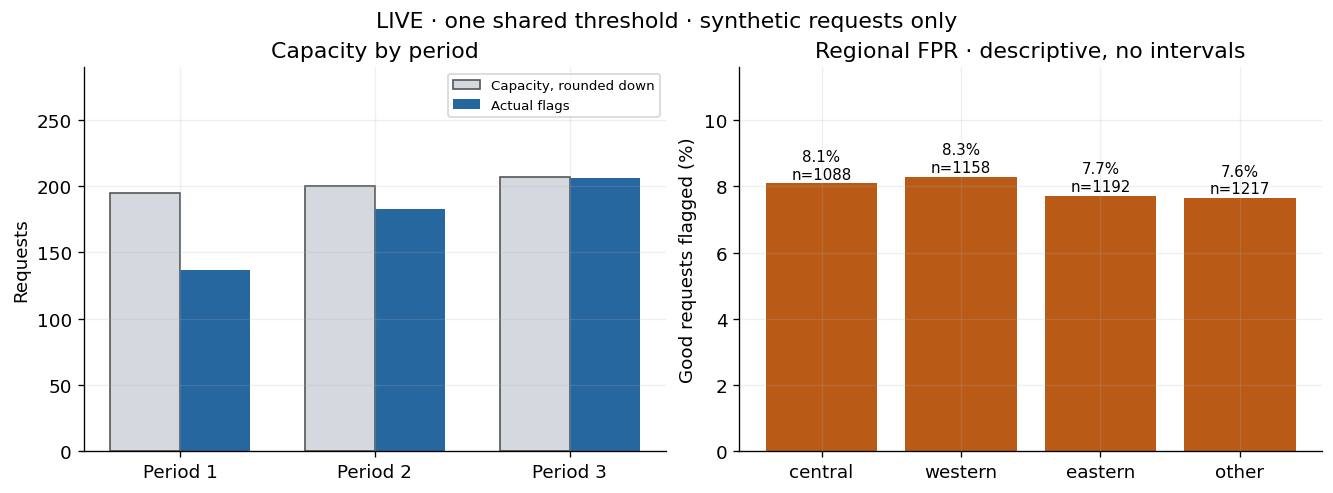

In [66]:
regions, gap_info = region_audit(selected, chosen["threshold"])
display(regions.round(4))
print("FPR gap (percentage points):", gap_info["fpr_gap_percentage_points"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
x = np.arange(len(periods))
axes[0].bar(x-.18, periods.capacity, .36, color="#D3D9DE", edgecolor="#555555", label="Capacity, rounded down")
axes[0].bar(x+.18, periods.flagged, .36, color="#2667A0", label="Actual flags")
axes[0].set(xticks=x, xticklabels=[f"Period {n}" for n in periods.fold], ylabel="Requests", title="Capacity by period")
axes[0].set_ylim(0, periods.capacity.max()*1.4)
axes[0].legend(fontsize=8)
axes[1].bar(regions.region, regions.false_positive_rate*100, color="#BA5A17")
axes[1].set(ylabel="Good requests flagged (%)", title="Regional FPR · descriptive, no intervals")
for i, row in enumerate(regions.itertuples()):
    if pd.notna(row.false_positive_rate):
        axes[1].text(i, row.false_positive_rate*100+.15, f"{row.false_positive_rate:.1%}\nn={row.negatives}", ha="center", fontsize=9)
axes[1].set_ylim(0, max(10, regions.false_positive_rate.max()*140))
fig.suptitle(f"{SOURCE} · one shared threshold · synthetic requests only")
fig.savefig(ARTIFACTS / "day3_capacity_regions.png", dpi=160)
plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. Write the decision argument yourself</h2>
<p>Complete the shared response cell in your own words and cite numbers from your run:</p>
<ol><li>Why the selected threshold is defensible.</li><li>The observed loss–capacity trade-off.</li><li>The regional FPR gap and what needs review.</li><li>Limitations: OOF development selection, coverage, calibration and simplified policy.</li><li>Why accuracy can mislead under class imbalance.</li><li>Why threshold selection uses OOF rather than training predictions or challenge data.</li></ol>
<p>Copying the threshold alone is insufficient. The automated checkpoint detects missing fields only; it does not judge correctness, assign a grade or establish authorship.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. اكتب حجة القرار بنفسك</h2>
<p>أكمل خلية الإجابات المشتركة بصياغتك أنت، واستشهد بأرقام من تشغيلك:</p>
<ol><li>لماذا يمكن الدفاع عن العتبة المختارة.</li><li>المقايضة المرصودة بين الخسارة والسعة.</li><li>فجوة FPR بين المناطق وما يحتاج إلى مراجعة.</li><li>القيود: اختيار تطويري على OOF، والتغطية، والمعايرة، وتبسيط السياسة.</li><li>لماذا قد تكون Accuracy مضللة مع عدم توازن الفئات.</li><li>لماذا نختار العتبة على OOF بدل تنبؤات التدريب أو بيانات التحدي.</li></ol>
<p>لا يكفي نسخ رقم العتبة. يكتشف الفحص الآلي الحقول الفارغة فقط؛ ولا يحكم على صحة الإجابة أو يمنح درجة أو يثبت الملكية.</p>
</td>
</tr>
</table>

In [67]:
responses = {
    "threshold_reason": (
        "The selected threshold is defensible because it reduces the simulated "
        "decision loss while respecting the 12% review-capacity limit."
    ),

    "cost_capacity_tradeoff": (
        "Lower thresholds can reduce false negatives, but they flag more applications. "
        "The selected threshold balances lower loss with the 12% review-capacity constraint."
    ),

    "regional_gap": (
        "The observed regional FPR gap was about 0.65 percentage points. "
        "This difference should be monitored across regions, but it is descriptive "
        "and does not by itself establish unfairness."
    ),

    "limitations": (
        "The threshold was selected using OOF development predictions covering 5,039 "
        "applications (50.39% of the full dataset). The results are not an independent "
        "final test, calibration is not guaranteed, and the cost and capacity policy is simplified."
    ),

    "why_accuracy_misleads": (
        "Accuracy can be misleading because the positive class is rare. "
        "A model can achieve high accuracy by predicting mostly negative cases while "
        "still missing many true defaults."
    ),

    "why_oof": (
        "OOF predictions are used because each prediction is generated for data that "
        "was not used to train that fold's model. Training predictions would be overly "
        "optimistic, while challenge data should remain separate from threshold selection."
    )
}

checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| missing:", checkpoint["missing"])

READY_FOR_REVIEW | missing: []



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. Decision Card and Evidence Export</h2>
<p>I executed the export cell, which created <code>reports/DECISION_CARD.md</code> using my actual run values and written interpretation, then saved the CSV, JSON and figure evidence.</p>
<ul><li><code>TECHNICAL_READY</code>: the live run and technical guards completed.</li><li><code>LEARNER_WORK_REQUIRED</code>: the technical work passed, but my interpretation remained incomplete.</li><li><code>READY_FOR_REVIEW</code>: the required text fields were present; this was not an automated grade.</li><li><code>EXAMPLE_ONLY_NOT_SUBMITTABLE</code>: the recovery example was used and could not represent my work.</li></ul>
<p>I downloaded <code>day3_artifacts.zip</code>, extracted it at the repository root and retained the generated <code>artifacts/</code> and <code>reports/</code> folders. I saved the executed notebook as <code>notebooks/03_cost_sensitive_decision.ipynb</code>. I ensured that the actual files were available in the repository because uploading only the ZIP would not satisfy the visible-file requirements.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. تصدير بطاقة القرار والأدلة</h2>
<p>شغّلت خلية التصدير التي أنشأت ملف <code>reports/DECISION_CARD.md</code> باستخدام قيم التشغيل الفعلية وتفسيري المكتوب، ثم حفظت أدلة CSV وJSON والرسوم.</p>
<ul><li><code>TECHNICAL_READY</code>: اكتمل التشغيل الفعلي وفحوص الحماية التقنية.</li><li><code>LEARNER_WORK_REQUIRED</code>: نجح الجانب التقني، لكن تفسيري كان لا يزال غير مكتمل.</li><li><code>READY_FOR_REVIEW</code>: كانت الحقول النصية المطلوبة موجودة؛ ولم تمثل هذه الحالة درجة آلية.</li><li><code>EXAMPLE_ONLY_NOT_SUBMITTABLE</code>: استُخدم مثال التعافي، ولم يكن صالحًا لتمثيل عملي.</li></ul>
<p>نزّلت ملف <code>day3_artifacts.zip</code>، وفككت ضغطه في جذر المستودع، واحتفظت بالمجلدين الناتجين <code>artifacts/</code> و<code>reports/</code>. وحفظت الدفتر المنفذ باسم <code>notebooks/03_cost_sensitive_decision.ipynb</code>. وتأكدت من توفر الملفات الفعلية داخل المستودع، لأن رفع ملف ZIP وحده لا يحقق متطلبات إظهار الملفات.</p>
</td>
</tr>
</table>


In [68]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [json_safe(v) for v in value]
    if isinstance(value, np.generic): value = value.item()
    if isinstance(value, float) and not np.isfinite(value): return None
    return value

checkpoint = reflection_check(responses, SOURCE)
status = "TECHNICAL_READY" if SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
pooled_ap = float(average_precision_score(selected[TARGET], selected.probability))
threshold_metrics = {"source": SOURCE, "technical_status": status, "strategy": MODEL_FOR_DECISION,
    "policy": asdict(policy), "unit": "educational_loss_unit", "comparison_operator": ">=",
    "capacity_scope": "every validation period; floor(fraction * period_rows)",
    "chosen": chosen, "unconstrained": unconstrained, "default_0_5": default,
    "loss_change_vs_default": delta, "pooled_oof_ap": pooled_ap, "regional_audit": gap_info,
    "coverage": coverage, "selection_status": "OOF development selection; not an independent final test"}
membership = train[["application_id", "application_date"]].copy()
membership["role"], membership["fold"] = "warmup_no_oof", 0
for fold in folds:
    membership.loc[fold["valid"], "role"] = "eligible_oof"
    membership.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
membership["source"] = SOURCE
decisions = selected.copy()
decisions["review_flag"] = flag_at(selected.probability, chosen["threshold"]).astype(int)
csv_outputs = {"day3_model_report.csv": model_report, "day3_model_comparison.csv": comparison,
    "day3_oof_predictions.csv": oof, "day3_oof_coverage.csv": membership, "threshold_sweep.csv": cost_curve,
    "day3_period_capacity.csv": periods, "day3_region_audit.csv": regions,
    "day3_cost_sensitivity.csv": sensitivity, "day3_review_flags.csv": decisions}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": status, "learner_status": checkpoint["status"], "source": SOURCE,
    "requested_config": asdict(config), "effective_config": effective_config, "assessment_mode": ASSESSMENT_MODE,
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "day2_revision": DAY2_REVISION, "day2_sha256": DAY2_SHA256, "manifest_sha256": MANIFEST_SHA256,
    "training_data_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
    "python": platform.python_version(), "elapsed_seconds": round(time.perf_counter()-RUN_STARTED,2),
    "coverage": coverage, "challenge_used_for_modeling": False, "no_automatic_grade": True}
if IN_COLAB:
    import resource
    run["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,1)
json_outputs = {"threshold_metrics.json": threshold_metrics, "day3_provenance.json": provenance,
    "day3_reflection.json": {"source": SOURCE, "responses": responses, "checkpoint": checkpoint}, "day3_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
rate_text = lambda value: f"{value:.2%}" if pd.notna(value) else "غير معرّفة لغياب المقام"
card_status = ("مثال تعليمي غير صالح للتسليم كتجربة شخصية" if SOURCE != "LIVE" else
               "مسودة — أكمل تفسيرك" if checkpoint["missing"] else "جاهزة للمراجعة؛ لا تعني اعتمادًا أو درجة")
card = f"""# بطاقة قرارك — Tamweel Lite

**الحالة:** {card_status}
**مصدر الأرقام:** {SOURCE} · **الاستراتيجية:** {MODEL_FOR_DECISION} · **الصفوف:** {len(selected):,} OOF

**المهمة:** الفئة الموجبة `default_within_90d=1` تعني حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. كل طية تحقق طلبات لاحقة، وتستبعد عملاءها من التدريب وتشترط نضج نتيجة التدريب قبل بدايتها. المعرّفات والتاريخ خارج المدخلات.

| الدليل | القيمة |
|---|---:|
| العتبة المقيدة، بالقيمة الكاملة | {repr(chosen['threshold'])} |
| عتبة أقل خسارة دون قيد | {repr(unconstrained['threshold'])} |
| Recall | {rate_text(chosen['recall'])} |
| Precision | {rate_text(chosen['precision'])} |
| AP مجمع منOOF | {pooled_ap:.4f} |
| الإشارات | {chosen['flagged']:,} من {len(selected):,} |
| FN / FP | {chosen['fn']} / {chosen['fp']} |
| الخسارة التعليمية | {chosen['loss_units']:.0f} وحدة |
| خسارة0.5 | {default['loss_units']:.0f} وحدة؛ ضمن السعة: {default['capacity_feasible']} |
| التغير عن0.5 | {delta:+.0f} وحدة؛ الموجب زيادة |
| خسارة لكل10,000 طلب، تطبيع حسابي | {chosen['loss_units_per_10000']:.2f} وحدة |
| فجوة معدل الإنذار الخاطئ بين المناطق | {gap_info['fpr_gap_percentage_points']:.3f} نقطة مئوية |

**القاعدة:** درجة ≥ {repr(chosen['threshold'])} تعني إشارة مراجعة داخل التمرين؛ غير ذلك بلا إشارة. لا تتخذ موافقة أو رفض تمويل حقيقي. احفظ الدقة الكاملة؛ تقريب العتبة قد يغيّر حجم الطابور.

**السياسة:** FN={policy.false_negative_cost:g} وFP={policy.false_positive_cost:g} وحدات تعليمية، وسعة {policy.max_flag_fraction:.0%} لكل فترة بعد التقريب لأسفل. ليست ريالات فعلية أو رسوم أدوات أو خصمًا من الدرجة.

**دليل السعة:** {', '.join(f"الفترة {int(row.fold)}: {int(row.flagged)}/{int(row.capacity)}" for row in periods.itertuples())}.

## لماذا اخترت هذه العتبة؟
{answer('threshold_reason')}

## الخسارة والسعة
{answer('cost_capacity_tradeoff')}

## فرق المناطق وما يحتاج إلى مراجعة
{answer('regional_gap')}

## حدود النتيجة
{answer('limitations')}

OOF تغطي {coverage['whole_data_coverage']:.2%} من التدريب و100% من الصفوف المؤهلة؛ {coverage['warmup_without_oof']:,} صفًا تمهيديًا بلا تنبؤ. اختيار العتبة وتقدير خسارتها هنا يستخدمان أهدافOOF نفسها؛ هذه نتيجة تطوير لا اختبار نهائي. لم نستخدم التحدي. المقارنة الجغرافية وصفية وليست شهادة عدالة، والأوزان لا تضمن معايرة الدرجات.

## سؤالك الأول: لماذا قد تخدعكAccuracy؟
{answer('why_accuracy_misleads')}

## سؤالك الثاني: لماذا تختار علىOOF؟
{answer('why_oof')}

أدلتك في `artifacts/threshold_metrics.json` و`day3_period_capacity.csv` و`day3_region_audit.csv` و`day3_cost_sensitivity.csv` و`cost_curve.png`. الحساسية سيناريوهات ±20% لخسارةFN، وليست فترات ثقة. راجع السعة والمعايرة عند تغير البيانات؛ لا تفترض ثباتهما مستقبلًا.
"""
(REPORTS / "DECISION_CARD.md").write_text(card, encoding="utf-8")
artifact_files = list(csv_outputs) + list(json_outputs) + ["cost_curve.png", "day3_roc_pr.png", "day3_capacity_regions.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day3_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files:
        bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "DECISION_CARD.md", "reports/DECISION_CARD.md")
print(f"{status} | {checkpoint['status']} | {SOURCE} | {run['elapsed_seconds']} seconds | CPU")
print(f"Saved {len(artifact_files)+1} files in day3_artifacts.zip — complete your reasoning and download.")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | 5.83 seconds | CPU
Saved 18 files in day3_artifacts.zip — complete your reasoning and download.


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Completion checkpoint and Day 4 bridge</h2>
<ul><li>You can identify FN and FP and explain the teaching loss matrix.</li><li>You can show capacity compliance for every period, not only in aggregate.</li><li>You compared weighting and oversampling without declaring a required winner.</li><li>You preserved the exact threshold and documented sensitivity and group-audit limits.</li><li>You saved the executed notebook, 17 artifact files and the decision card outside the temporary Colab session.</li></ul>
<p><strong>Troubleshooting:</strong> restart after an imported-version mismatch; rerun setup after a network interruption; never bypass a checksum; rerun live CPU training if the educational example appears; never submit another learner’s outputs.</p>
<p><strong>Day 4:</strong> inspect global and local explanations, test calibration and decide whether the score can be interpreted as a probability.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>بوابة الإكمال والربط باليوم الرابع</h2>
<ul><li>تستطيع تحديد FN وFP وشرح مصفوفة الخسارة التعليمية.</li><li>تستطيع إثبات الالتزام بالسعة في كل فترة، وليس في المجموع فقط.</li><li>قارنت الوزن وإعادة العينات دون افتراض فائز مطلوب.</li><li>حفظت العتبة بكامل دقتها ووثقت الحساسية وحدود تدقيق المجموعات.</li><li>حفظت الدفتر المنفذ و17 ملف دليل وبطاقة القرار خارج جلسة Colab المؤقتة.</li></ul>
<p><strong>حل التعثر:</strong> أعد تشغيل الجلسة عند اختلاف إصدار مستورد؛ أعد الإعداد بعد انقطاع الشبكة؛ لا تتجاوز فحص البصمة؛ أعد التدريب الفعلي على CPU عند ظهور المثال التعليمي؛ ولا تسلّم مخرجات متدرب آخر.</p>
<p><strong>اليوم الرابع:</strong> افحص التفسير العالمي والمحلي، واختبر المعايرة، وقرر هل يمكن تفسير الدرجة بوصفها احتمالًا.</p>
</td>
</tr>
</table>

# **SHAP & calibration | التفسير والمعايرة**



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. Controlled Environment Preparation</h2>
<p>I prepared a fresh free-CPU session and selected <strong>Runtime → Run all</strong>. I verified the pinned packages, file hashes and support assets before starting any model work.</p>
<ul>
<li>I kept <code>FAST_MODE=True</code> and <code>USE_SHAP_EXAMPLE=False</code> for the primary run.</li>
<li>I limited execution to a maximum of two CPU threads without requiring a GPU, Google Drive mount, API key or paid service.</li>
<li>I froze the fitted estimator before calibration. I used <code>FrozenEstimator</code> to enable sigmoid calibration without retraining the model on calibration rows.</li>
<li>I preserved the time/customer role split instead of replacing it with a random split.</li>
</ul>
<p>I followed the setup requirement to restart the session and rerun everything from the beginning if a restart was requested. I also maintained checksum verification without bypassing any failure.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. إعداد بيئة تشغيل محكومة</h2>
<p>جهّزت جلسة جديدة باستخدام CPU مجاني، واخترت <strong>Runtime → Run all</strong>. وتحققت من إصدارات الحزم المثبتة وبصمات الملفات وأصول الدعم قبل البدء بأي عمل على النموذج.</p>
<ul>
<li>أبقيت <code>FAST_MODE=True</code> و<code>USE_SHAP_EXAMPLE=False</code> في التشغيل الأساسي.</li>
<li>حددت التنفيذ باستخدام خيطَي CPU كحد أقصى، دون الحاجة إلى GPU أو ربط Google Drive أو مفتاح API أو أي خدمة مدفوعة.</li>
<li>جمّدت النموذج المدرّب قبل المعايرة، واستخدمت <code>FrozenEstimator</code> لإجراء معايرة sigmoid دون إعادة تدريب النموذج على صفوف المعايرة.</li>
<li>حافظت على تقسيم البيانات بحسب الزمن والعملاء، ولم أستبدله بتقسيم عشوائي.</li>
</ul>
<p>التزمت بمتطلبات الإعداد التي تستلزم إعادة تشغيل الجلسة وتنفيذ جميع الخطوات من البداية عند طلب إعادة التشغيل. كما حافظت على التحقق من بصمات الملفات دون تجاوز أي فشل في التحقق.</p>
</td>
</tr>
</table>


In [69]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
PREVIOUS_SUPPORT = {
    "scripts/day2_validation.py": ("1e1da4acbee8941bef07245b259fb6c27ced4ad7", "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"),
    "scripts/day3_decision.py": ("c2dc52e129878d0d487db1874891c658de7c4d0d", "40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12")}
for relative, (revision, digest) in PREVIOUS_SUPPORT.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{revision}/{relative}", ROOT / relative, digest)
LAB_REVISION = "4f6892d5c02923b5f8e3c78f4fcead73b043570f"
SUPPORT_HASHES = {'scripts/day4_trust.py': '7e0f54bdbed94b28d09cddd02ce0ba0471d5046f05c7b70589e3e4be9902f20c', 'data/day4_shap_example.npz': 'de6eefb4f0b1dfd54d4a71e2b73cf8383cea6386e661f8af8662d478cd957e2b', 'data/day4_shap_example.json': '8169c70dc327a7ffdff748c365d71544fe951f3b196974e33f09dccb580a8122'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}", ROOT / relative, digest)
print("Day 4 setup verified | إعداد اليوم الرابع جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 4 setup verified | إعداد اليوم الرابع جاهز



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. Separation of Model Fitting, Calibration, Policy and Evaluation</h2>
<p>I worked with a synthetic target representing a default event within 90 days after application. I reserved customers assigned to newer roles first and excluded them from earlier roles. I also ensured that identifiers and dates were not used as model features.</p>
<table>
<tr><th>Role</th><th>Period or Condition</th><th>Purpose in My Workflow</th></tr>
<tr><td><code>fit</code></td><td>Outcome matured before 2023-07-01</td><td>I learned imputation and trained the weighted model.</td></tr>
<tr><td><code>calibration</code></td><td>Jul–Sep 2023</td><td>I used this period only to learn sigmoid calibration.</td></tr>
<tr><td><code>policy</code></td><td>Jan–Mar 2024</td><td>I selected the threshold minimizing 10×FN+FP under the 12% capacity limit.</td></tr>
<tr><td><code>evaluation</code></td><td>Jul–Dec 2024</td><td>I measured and explained model performance after freezing the model and policy.</td></tr>
</table>
<p>I kept gap periods and conflicting-customer rows excluded. I maintained a separate evaluation role within this lab while acknowledging that these data had appeared earlier in the course, so they did not constitute a final untouched test. I also kept the challenge data closed.</p>
<p>For <code>FAST</code> mode, I used 80 trees, 300 SHAP rows, three permutations and 200 customer-cluster bootstrap replicates. I treated <code>FULL</code> as an optional mode with 160 trees, 600 rows, five permutations and 500 replicates. I interpreted the ±0.02 review zone as an operational scenario rather than a confidence interval.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. فصل تدريب النموذج والمعايرة والسياسة والتقييم</h2>
<p>عملت على هدف اصطناعي يمثّل وقوع حدث تعثر خلال 90 يومًا بعد تقديم الطلب. خصصت بيانات العملاء المرتبطين بالأدوار الأحدث أولًا، واستبعدتهم من الأدوار السابقة. كما تأكدت من عدم استخدام المعرّفات والتواريخ ضمن خصائص النموذج.</p>
<table>
<tr><th>الدور</th><th>الفترة أو الشرط</th><th>استخدامي للبيانات</th></tr>
<tr><td><code>fit</code></td><td>نضجت النتيجة قبل 2023-07-01</td><td>تعلمت تعويض القيم المفقودة ودرّبت النموذج الموزون.</td></tr>
<tr><td><code>calibration</code></td><td>يوليو–سبتمبر 2023</td><td>استخدمت هذه الفترة لتعلم معايرة sigmoid فقط.</td></tr>
<tr><td><code>policy</code></td><td>يناير–مارس 2024</td><td>اخترت العتبة التي تقلل خسارة 10×FN+FP ضمن حد السعة البالغ 12%.</td></tr>
<tr><td><code>evaluation</code></td><td>يوليو–ديسمبر 2024</td><td>قست أداء النموذج وفسّرته بعد تثبيت النموذج والسياسة.</td></tr>
</table>
<p>أبقيت فترات الفجوات وصفوف العملاء المتعارضين مستبعدة. وحافظت على فصل بيانات التقييم داخل هذا اللاب، مع إدراكي أنها ظهرت سابقًا خلال الدورة، ولذلك لا تُعد اختبارًا نهائيًا لم يُستخدم من قبل. كما أبقيت بيانات التحدي مغلقة.</p>
<p>في وضع <code>FAST</code>، استخدمت 80 شجرة و300 صف لتحليل SHAP وثلاثة تبديلات و200 عملية إعادة سحب bootstrap على مستوى مجموعات العملاء. وتعاملت مع وضع <code>FULL</code> بوصفه خيارًا إضافيًا يتضمن 160 شجرة و600 صف وخمسة تبديلات و500 عملية إعادة سحب. وفسّرت نطاق المراجعة ±0.02 بوصفه سيناريو تشغيليًا، وليس فترة ثقة.</p>
</td>
</tr>
</table>


In [70]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from scipy.special import expit
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications
from day4_trust import (TARGET, ROLES, TrustConfig, split_roles, fit_and_calibrate,
    probability_metrics, reliability_table, permutation_report, explain_sample, load_shap_example,
    ShapBudgetExpired, reason_codes, local_stability, cluster_bootstrap, choose_policy_threshold,
    transport_threshold, map_probability, review_audit, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = TrustConfig() if FAST_MODE else TrustConfig(trees=160, shap_rows=600, permutation_repeats=5, bootstrap_repeats=500)
USE_SHAP_EXAMPLE = False  # Discussion only; not a personal submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
parts, assignments = split_roles(train)
role_summary = pd.DataFrame([{"role": r, "rows": len(p), "customers": p.customer_id.nunique(),
    "positives": int(p[TARGET].sum()), "positive_rate": p[TARGET].mean(),
    "first_date": p.application_date.min(), "last_date": p.application_date.max()} for r, p in parts.items()])
display(role_summary)
print("Excluded gaps/customer overlaps:", int((assignments.role == "excluded_gap_or_customer").sum()))
model, calibrated_model, predictions, provenance = fit_and_calibrate(parts, contract, config)
evaluation = predictions[predictions.role == "evaluation"].copy()
policy_rows = predictions[predictions.role == "policy"].copy()
chosen_policy, policy_sweep = choose_policy_threshold(policy_rows)
mapping = provenance["calibration_mapping"]
calibrated_threshold = transport_threshold(chosen_policy["threshold"], mapping)
print("Model, sigmoid and policy threshold frozen before evaluation.")

,role,rows,customers,positives,positive_rate,first_date,last_date
0,fit,2516,1853,217,0.086248,2022-01-01,2023-04-01
1,calibration,584,538,40,0.068493,2023-07-01,2023-09-30
2,policy,589,566,55,0.093379,2024-01-01,2024-03-31
3,evaluation,1733,1520,139,0.080208,2024-07-01,2024-12-31


Excluded gaps/customer overlaps: 4578
Model, sigmoid and policy threshold frozen before evaluation.



<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. Measuring Held-Out Model Dependence Using Permutation Importance</h2>
<p>I used permutation importance to measure the decrease in <strong>Average Precision</strong> when shuffling feature groups on evaluation rows without retraining the model. I shuffled the three region indicators together to avoid creating impossible region combinations during the audit.</p>
<p>I distinguished between training gain and held-out permutation importance because they answer different questions. I retained negative decreases and interpreted the standard deviation across repeats as variability between permutations, not a confidence interval. I also considered how correlated features could share predictive signal, making their individual importance appear smaller.</p>
<p>I maintained the independence limitations of the evaluation period by not using its results to redesign features and then treating the same period as an independent evaluation.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. قياس اعتماد النموذج على الخصائص باستخدام Permutation Importance</h2>
<p>استخدمت أهمية التبديل (Permutation Importance) لقياس الانخفاض في <strong>Average Precision</strong> عند تبديل مجموعات الخصائص داخل صفوف التقييم دون إعادة تدريب النموذج. وبدّلت مؤشرات المنطقة الثلاثة معًا لتجنب إنشاء تركيبات إقليمية غير ممكنة أثناء التدقيق.</p>
<p>ميّزت بين مكسب التدريب وأهمية التبديل على بيانات التقييم، لأن كلًا منهما يجيب عن سؤال مختلف. واحتفظت بقيم الانخفاض السالبة، وفسّرت الانحراف المعياري عبر التكرارات بوصفه مقياسًا للتباين بين عمليات التبديل، وليس فترة ثقة. كما أخذت في الاعتبار أن الخصائص المترابطة قد تتشارك الإشارة التنبؤية، مما يجعل أهمية كل خاصية منفردة تبدو أقل.</p>
<p>حافظت على حدود استقلالية فترة التقييم، فلم أستخدم نتائجها لإعادة تصميم الخصائص ثم أتعامل مع الفترة نفسها بوصفها تقييمًا مستقلًا.</p>
</td>
</tr>
</table>


,feature_group,mean_ap_drop,repeat_sd,training_gain
0,bureau_score,0.1270,0.0235,8922.6701
1,dti,0.0690,0.0200,6423.5164
2,loan_amount_sar,0.0140,0.0095,2372.2859
3,savings_balance_sar,0.0094,0.0032,2129.8893
4,prior_defaults,0.0065,0.0021,1109.2766
5,recent_inquiries,0.0064,0.0089,902.9509
6,income_sar,0.0062,0.0058,2214.5619
7,utilization_ratio,0.0057,0.0011,2035.9451
8,region_indicators_joint,0.0047,0.0020,360.9725
9,months_employed,0.0025,0.0044,2482.2264


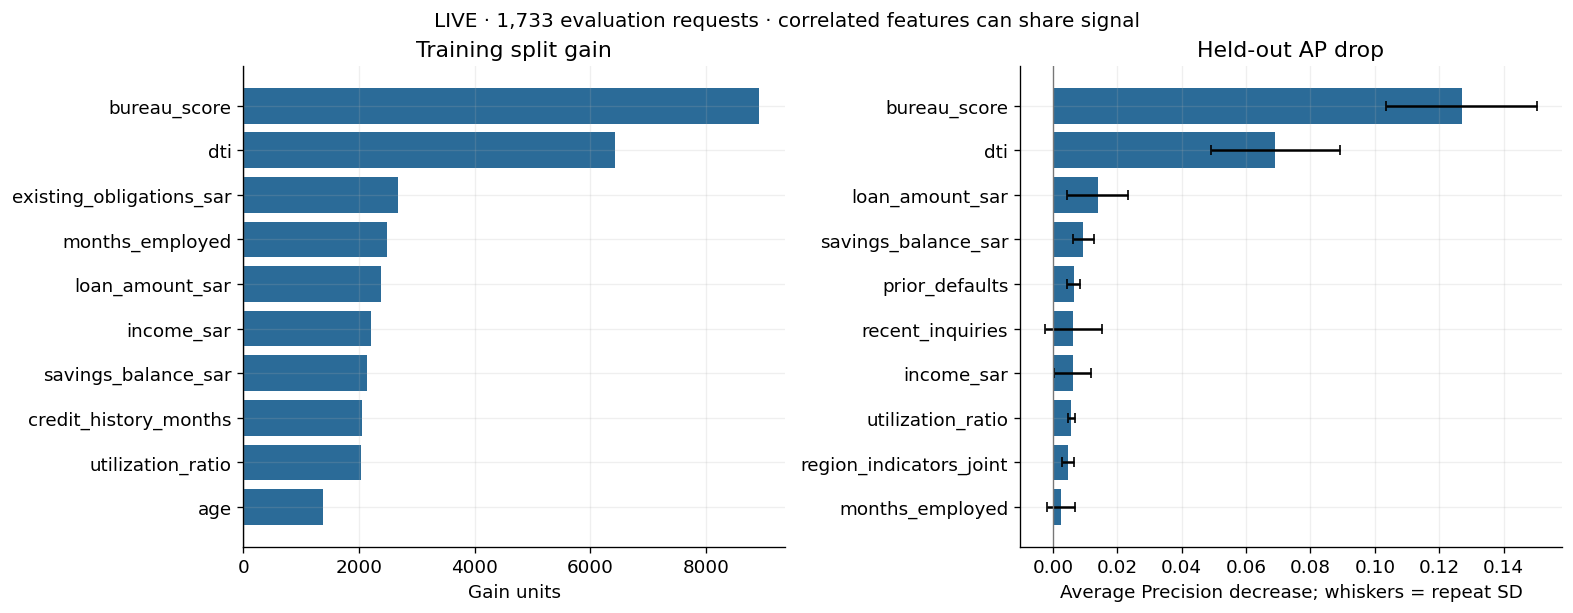

In [71]:
permutation = permutation_report(model, parts["evaluation"], contract, config)
display(permutation[["feature_group", "mean_ap_drop", "repeat_sd", "training_gain"]].head(10).round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for ax, value, title in [(axes[0], "training_gain", "Training split gain"), (axes[1], "mean_ap_drop", "Held-out AP drop")]:
    top = permutation.nlargest(10, value).sort_values(value)
    ax.barh(top.feature_group, top[value], color="#2b6b98",
            xerr=top.repeat_sd if value == "mean_ap_drop" else None, capsize=3)
    ax.axvline(0, color="#777", lw=.8); ax.set_title(title)
    ax.set_xlabel("Gain units" if value == "training_gain" else "Average Precision decrease; whiskers = repeat SD")
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · correlated features can share signal", fontsize=12)
fig.savefig(ARTIFACTS / "permutation_importance.png", bbox_inches="tight"); plt.show()


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. Global SHAP Interpretation and Contribution Units</h2>
<p>I used TreeSHAP to explain a fixed random sample from the evaluation data for the raw weighted model. I used the training tree-path distribution as the background, while the displayed feature values represented the model inputs after imputation learned exclusively from the <code>fit</code> data.</p>
<p>I interpreted the relationship as <strong>raw margin = base value + Σ SHAP</strong>, followed by <strong>raw probability = sigmoid(raw margin)</strong>. I recognized that SHAP contributions were measured in <strong>log-odds</strong>, not probability points. I therefore did not transform each contribution separately and add the transformed values. I also recognized that <code>sigmoid(base_value)</code> was not necessarily equal to the mean predicted probability.</p>
<p>I interpreted the SHAP beeswarm plot using four elements: mean absolute SHAP magnitude to rank features, contribution sign to identify score direction, colour to represent feature values and spread to examine heterogeneous effects. I treated these explanations as evidence of model behaviour, not proof of causality or fairness.</p>
<p>I distinguished any labelled educational example from my actual analysis, recognizing that such an example was intended only for discussion and could not be submitted as my own run.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. تفسير SHAP العام وفهم وحدات المساهمات</h2>
<p>استخدمت TreeSHAP لتفسير عينة عشوائية ثابتة من بيانات التقييم للنموذج الخام الموزون. واعتمدت على توزيع مسارات أشجار التدريب بوصفه الخلفية، بينما مثّلت قيم الخصائص المعروضة مدخلات النموذج بعد تعويض القيم المفقودة باستخدام ما تعلمته من بيانات <code>fit</code> فقط.</p>
<p>فسّرت العلاقة وفق <strong>raw margin = base value + Σ SHAP</strong>، ثم <strong>raw probability = sigmoid(raw margin)</strong>. وأدركت أن مساهمات SHAP تُقاس بوحدة <strong>log-odds</strong> وليست نقاطًا احتمالية. لذلك لم أحوّل كل مساهمة بصورة منفصلة ثم أجمع القيم المحوّلة. كما أدركت أن <code>sigmoid(base_value)</code> لا يساوي بالضرورة متوسط الاحتمالات المتوقعة.</p>
<p>فسّرت مخطط SHAP beeswarm بالاعتماد على أربعة عناصر: متوسط القيمة المطلقة لمساهمات SHAP لترتيب الخصائص، وإشارة المساهمة لتحديد اتجاه الدرجة، واللون لتمثيل قيمة الخاصية، والانتشار لفحص اختلاف التأثيرات. وتعاملت مع هذه التفسيرات بوصفها أدلة على سلوك النموذج، وليست إثباتًا للسببية أو العدالة.</p>
<p>ميّزت بين أي مثال تعليمي موسوم وتحليلي الفعلي، مع إدراكي أن هذا المثال مخصص للمناقشة فقط ولا يمكن تقديمه بوصفه نتيجة تشغيل نفذتها بنفسي.</p>
</td>
</tr>
</table>


,feature,mean_absolute_shap_log_odds
4,bureau_score,0.9042
5,dti,0.5437
2,loan_amount_sar,0.3490
10,savings_balance_sar,0.2169
9,existing_obligations_sar,0.2022
8,prior_defaults,0.1830
6,months_employed,0.1584
1,income_sar,0.1549
7,recent_inquiries,0.1492
13,utilization_ratio,0.1287


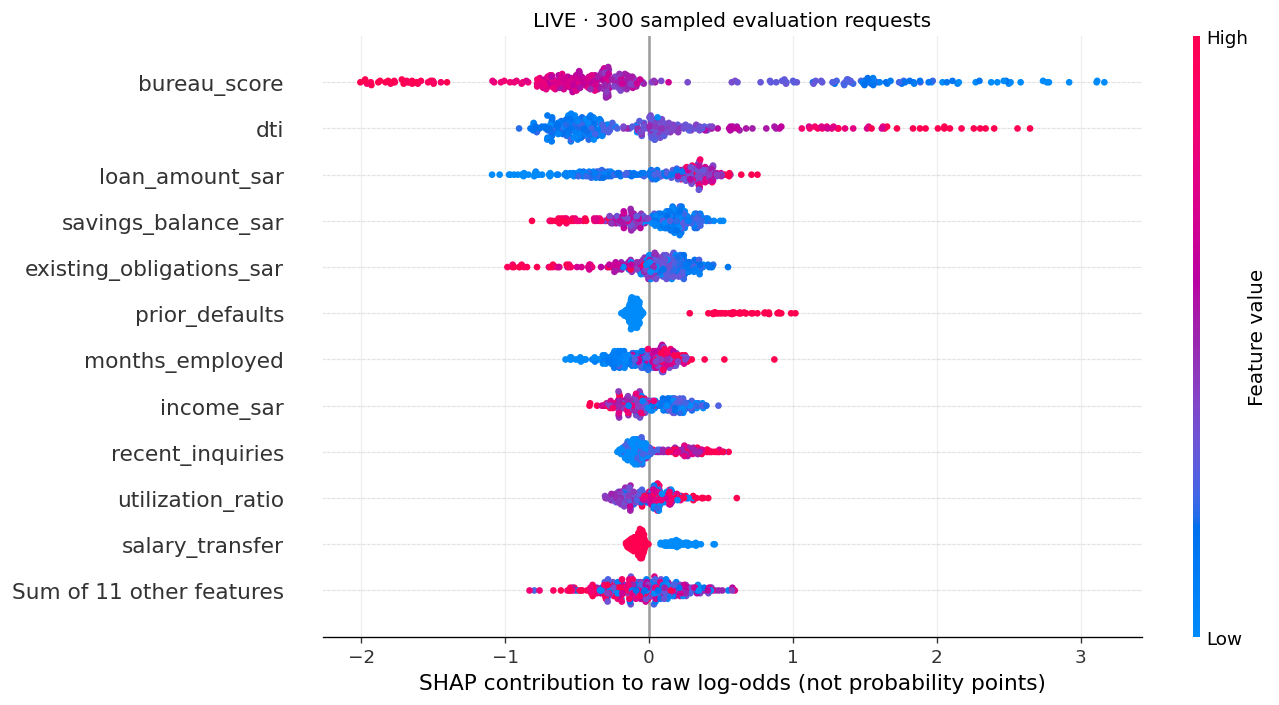

Maximum additivity error: 5.6968318951078345e-15


In [72]:
try:
    if USE_SHAP_EXAMPLE:
        raise ShapBudgetExpired("Educational example requested.")
    shap_arrays, shap_metadata = explain_sample(model, parts["evaluation"], contract, config)
except ShapBudgetExpired:
    shap_arrays, shap_metadata = load_shap_example(ROOT / "data/day4_shap_example.npz",
        ROOT / "data/day4_shap_example.json", model, parts["evaluation"], contract, ASSESSMENT_MODE)

import shap
EXPLANATION_SOURCE = shap_metadata["source"]
if EXPLANATION_SOURCE != "LIVE":
    print("EDUCATIONAL_EXAMPLE — مثال موسوم للمناقشة، غير صالح للتسليم كتجربتك. أعد SHAP لاحقًا.")
explanation = shap.Explanation(values=shap_arrays["values"], base_values=shap_arrays["base_values"],
    data=shap_arrays["data"], feature_names=list(shap_arrays["feature_names"]))
shap_global = pd.DataFrame({"feature": shap_arrays["feature_names"],
    "mean_absolute_shap_log_odds": np.abs(shap_arrays["values"]).mean(axis=0)}).sort_values("mean_absolute_shap_log_odds", ascending=False)
display(shap_global.head(10).round(4))
plt.figure()
shap.plots.beeswarm(explanation, max_display=12, show=False, plot_size=(11, 6.5))
plt.xlabel("SHAP contribution to raw log-odds (not probability points)")
plt.title(f"{EXPLANATION_SOURCE} · {len(shap_arrays['application_ids'])} sampled evaluation requests", fontsize=12)
plt.savefig(ARTIFACTS / "shap_beeswarm.png", bbox_inches="tight"); plt.show()
print("Maximum additivity error:", shap_metadata["max_additivity_error"])

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. Explain one high-score synthetic request</h2>
<p>The lab selects the highest raw score inside the SHAP sample without using the observed outcome. The waterfall displays the largest contributions and groups the remainder; the complete contribution vector is preserved in the evidence file.</p>
<p>At most three reason statements are derived from actual positive contributions. Check whether the displayed input was imputed before interpreting it. A positive contribution does not mean the feature is always high, and changing the feature does not guarantee a changed outcome.</p>
<p>The <code>bureau_score ±1</code> perturbation is a narrow local stability check. It is not a guarantee for every request, feature or future period.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. فسّر طلبًا اصطناعيًا مرتفع الدرجة</h2>
<p>يختار اللاب أعلى درجة خام داخل عينة SHAP دون استخدام النتيجة المرصودة. تعرض waterfall أكبر الإسهامات وتجمع البقية، مع حفظ متجه الإسهامات الكامل في ملف الأدلة.</p>
<p>تُشتق ثلاث عبارات سبب كحد أقصى من الإسهامات الموجبة الفعلية. تحقّق أولًا هل القيمة المعروضة عُوّضت قبل تفسيرها. لا تعني المساهمة الموجبة أن الخاصية مرتفعة دائمًا، ولا يضمن تغيير الخاصية تغير النتيجة.</p>
<p>اختبار <code>bureau_score ±1</code> فحص محلي ضيق للاستقرار، وليس ضمانًا لكل طلب أو خاصية أو فترة مستقبلية.</p>
</td>
</tr>
</table>

TR-009585 | raw score=0.9031 | calibrated probability=0.4795


,feature,value_used,was_imputed,contribution_log_odds,reason_ar
0,bureau_score,497.0000,False,2.269325,استخدم النموذج درجة ائتمانية اصطناعية عند الطل...
1,dti,1.2806,False,1.198145,استخدم النموذج نسبة الالتزام مع القسط المقترح ...
2,loan_amount_sar,93437.2900,False,0.200725,استخدم النموذج مبلغ التمويل المطلوب بالقيمة 93...


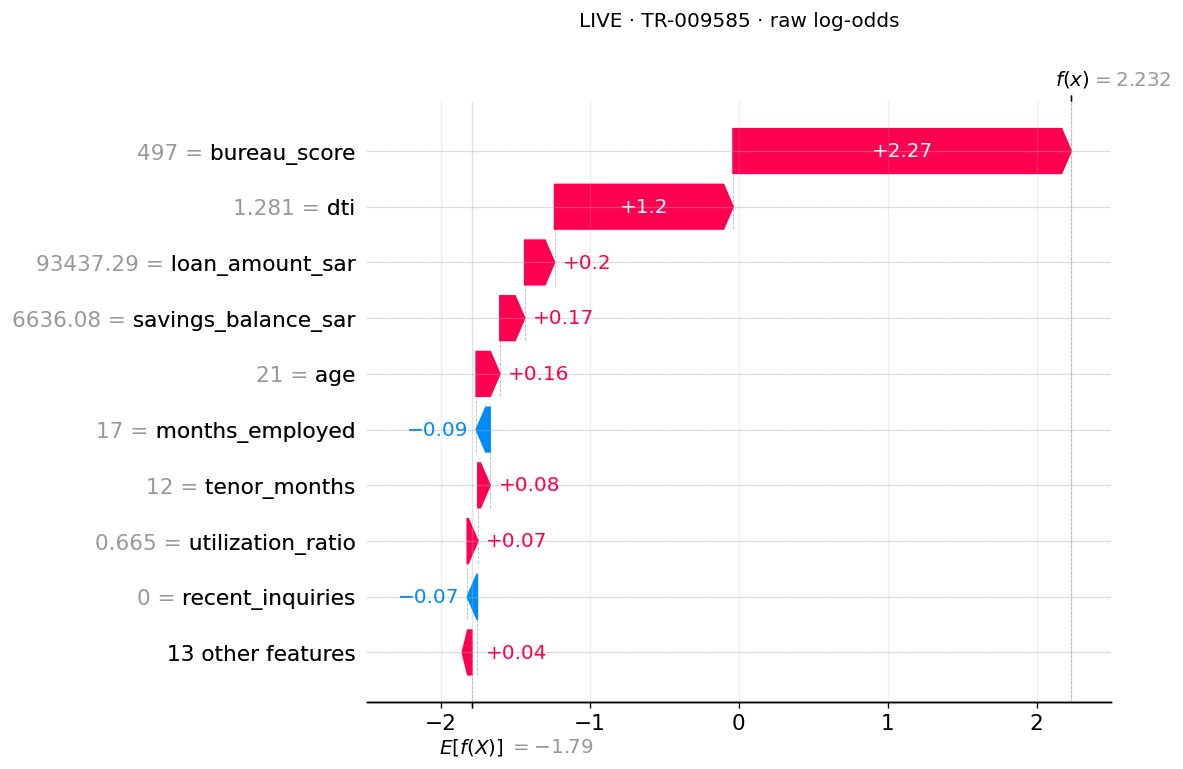

,perturbation,bureau_score_used,raw_probability,calibrated_probability,top_positive_features,shared_top_reasons,reference_reasons,source
0,bureau_score +0,497.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
1,bureau_score -1,496.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
2,bureau_score +1,498.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE


In [73]:
local_index = int(np.argmax(shap_arrays["raw_margin"]))
local_id = str(shap_arrays["application_ids"][local_index])
case = parts["evaluation"].set_index("application_id", drop=False).loc[[local_id]]
descriptions = {f["name"]: f["description_ar"] for f in contract["features"]}
reasons = reason_codes(shap_arrays["values"][local_index], shap_arrays["feature_names"],
    shap_arrays["data"][local_index], descriptions)
reasons["application_id"] = local_id
reasons["was_imputed"] = [bool(case.iloc[0][feature] != case.iloc[0][feature]) for feature in reasons.feature]
reasons["source"] = EXPLANATION_SOURCE
raw_local = float(expit(shap_arrays["raw_margin"][local_index]))
cal_local = float(map_probability(raw_local, mapping))
print(f"{local_id} | raw score={raw_local:.4f} | calibrated probability={cal_local:.4f}")
display(reasons[["feature", "value_used", "was_imputed", "contribution_log_odds", "reason_ar"]])
plt.figure()
shap.plots.waterfall(explanation[local_index], max_display=10, show=False)
plt.title(f"{EXPLANATION_SOURCE} · {local_id} · raw log-odds", fontsize=12, pad=45)
plt.savefig(ARTIFACTS / "shap_waterfall.png", bbox_inches="tight"); plt.show()
if EXPLANATION_SOURCE == "LIVE":
    local_checks = local_stability(model, case, contract, mapping)
    local_checks["source"] = "LIVE"
    display(local_checks)
else:
    local_checks = pd.DataFrame(columns=["perturbation", "bureau_score_used", "raw_probability", "calibrated_probability",
        "top_positive_features", "shared_top_reasons", "reference_reasons", "source"])
    print("Local perturbation check skipped in example mode; do not claim it ran.")

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. Test calibration on a separate period</h2>
<p>Sigmoid is learned on calibration rows only, without new class weights. The fitted model and calibrator are then frozen and measured on evaluation.</p>
<p>Compare ROC-AUC and Average Precision for ranking, and Brier score, log-loss and ECE for probability quality. A lower Brier score alone does not prove perfect calibration.</p>
<p>ECE uses ten equal-width bins: Σ(bin count ÷ all rows × |mean probability − observed rate|). Empty bins remain visible and every bin count is reported. ECE depends on bin boundaries and sample size; sparse bins are weak evidence.</p>
<p>A single monotone sigmoid mapping preserves the ordering of this model, but calibration is not guaranteed to improve. Isotonic calibration is optional and requires caution with the small number of calibration positives.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. اختبر المعايرة على فترة منفصلة</h2>
<p>يتعلم sigmoid من صفوف calibration فقط دون أوزان فئات جديدة. ثم يُثبّت النموذج والمعاير وتُقاس النتائج على evaluation.</p>
<p>قارن ROC-AUC وAverage Precision للترتيب، وBrier وlog-loss وECE لجودة الاحتمال. لا يثبت انخفاض Brier وحده المعايرة المثالية.</p>
<p>يستخدم ECE عشر حاويات متساوية العرض: مجموع (عدد الحاوية ÷ جميع الصفوف × |متوسط الاحتمال − التكرار المرصود|). تبقى الحاويات الفارغة ظاهرة ويُعرض عدد كل حاوية. يتأثر ECE بحدود الحاويات وحجم العينة؛ الحاويات القليلة دليل ضعيف.</p>
<p>يحافظ تحويل sigmoid المتزايد الواحد على ترتيب هذا النموذج، لكن التحسن غير مضمون. المعايرة isotonic توسع اختياري يحتاج حذرًا مع قلة الموجبات في عينة المعايرة.</p>
</td>
</tr>
</table>

,rows,positives,roc_auc,average_precision,brier,ece,log_loss
raw,1733,139,0.770804,0.258677,0.113027,0.146871,0.357993
sigmoid,1733,139,0.770804,0.258677,0.067112,0.022486,0.246749


Measured change (after - before): Brier -0.04592, ECE -0.12438


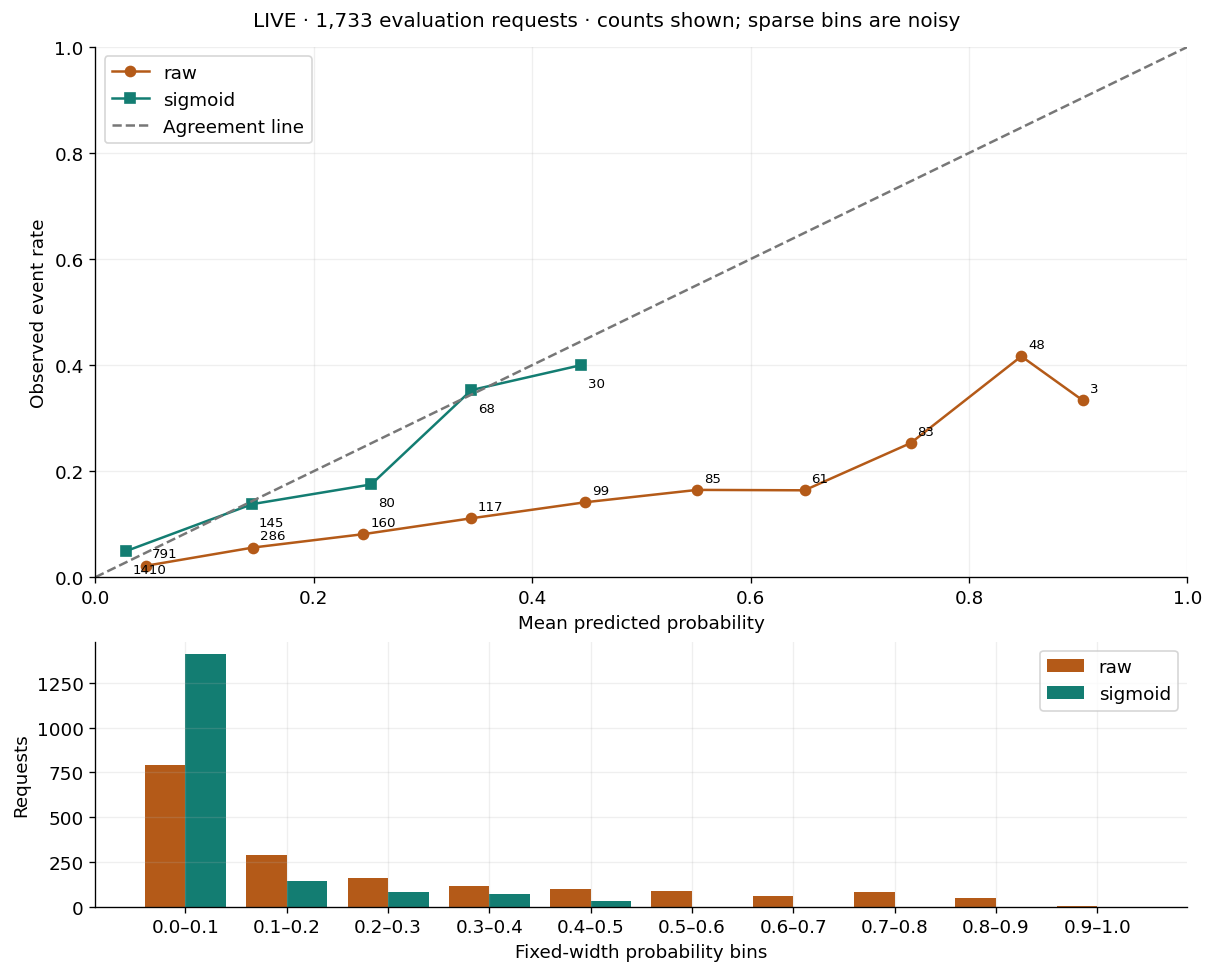

In [74]:
calibration_metrics, bin_tables = {}, []
for label, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
    calibration_metrics[label] = probability_metrics(evaluation[TARGET], evaluation[column])
    table = reliability_table(evaluation[TARGET], evaluation[column]); table["variant"] = label
    bin_tables.append(table)
reliability = pd.concat(bin_tables, ignore_index=True)
display(pd.DataFrame(calibration_metrics).T[["rows", "positives", "roc_auc", "average_precision", "brier", "ece", "log_loss"]].round(5))
brier_delta = calibration_metrics["sigmoid"]["brier"] - calibration_metrics["raw"]["brier"]
ece_delta = calibration_metrics["sigmoid"]["ece"] - calibration_metrics["raw"]["ece"]
print(f"Measured change (after - before): Brier {brier_delta:+.5f}, ECE {ece_delta:+.5f}")
fig, axes = plt.subplots(2, 1, figsize=(10, 8), layout="constrained", gridspec_kw={"height_ratios": [2, 1]})
for label, color, marker in [("raw", "#b45a18", "o"), ("sigmoid", "#137d72", "s")]:
    bins = reliability[reliability.variant == label]; nonempty = bins[bins['count'] > 0]
    axes[0].plot(nonempty.mean_probability, nonempty.observed_rate, marker=marker, color=color, label=label)
    for row in nonempty.itertuples():
        axes[0].annotate(str(row.count), (row.mean_probability, row.observed_rate), xytext=(4, 5 if label == "raw" else -13), textcoords="offset points", fontsize=8)
    positions = bins['bin'] + (-.2 if label == "raw" else .2)
    axes[1].bar(positions, bins['count'], width=.4, color=color, label=label)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#777", label="Agreement line")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted probability", ylabel="Observed event rate")
axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].set(xticks=np.arange(10), xticklabels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], ylabel="Requests", xlabel="Fixed-width probability bins")
axes[1].legend()
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · counts shown; sparse bins are noisy", fontsize=12)
fig.savefig(ARTIFACTS / "reliability_curve.png", bbox_inches="tight"); plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. Quantify what the stability interval does and does not cover</h2>
<p>The paired bootstrap samples <strong>customers</strong>, keeping each customer's requests together, and compares raw versus calibrated results on the same replicates. It reports 95% percentile intervals for AP and Brier change.</p>
<p>The model and calibrator remain fixed. The interval therefore excludes uncertainty from model training, calibration fitting and future temporal drift. It is not a confidence interval for one applicant's probability.</p>
<p>Quarter-level evaluation metrics describe temporal variation. They are not three independent folds or a confidence interval. Any change designed after viewing evaluation needs new evidence.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. حدّد ما تغطيه فترة الاستقرار وما لا تغطيه</h2>
<p>يسحب bootstrap المزدوج <strong>العملاء</strong> مع إبقاء طلبات العميل معًا، ويقارن النتائج الخام والمعايرة على السحبات نفسها. يعرض فترات مئينية 95% لـAP وتغير Brier.</p>
<p>يبقى النموذج والمعاير ثابتين؛ لذلك لا تشمل الفترة عدم يقين تدريب النموذج أو تعلم المعايرة أو الانجراف الزمني المستقبلي. كما أنها ليست فترة ثقة لاحتمال طلب واحد.</p>
<p>تصف مقاييس أرباع التقييم التغير الزمني، وليست طيات مستقلة أو فترة ثقة. أي تعديل يُصمم بعد رؤية التقييم يحتاج إلى دليل جديد.</p>
</td>
</tr>
</table>

,period,variant,rows,positives,average_precision,brier,ece
0,2024Q3,raw,836,78,0.27457,0.11528,0.13397
1,2024Q3,sigmoid,836,78,0.27457,0.07760,0.03229
2,2024Q4,raw,897,61,0.27050,0.11093,0.15890
3,2024Q4,sigmoid,897,61,0.27050,0.05734,0.02434


Paired customer-cluster 95% percentile intervals:


,lower,upper
raw_ap,0.197442,0.337854
calibrated_ap,0.197442,0.337854
brier_change,-0.054177,-0.037409


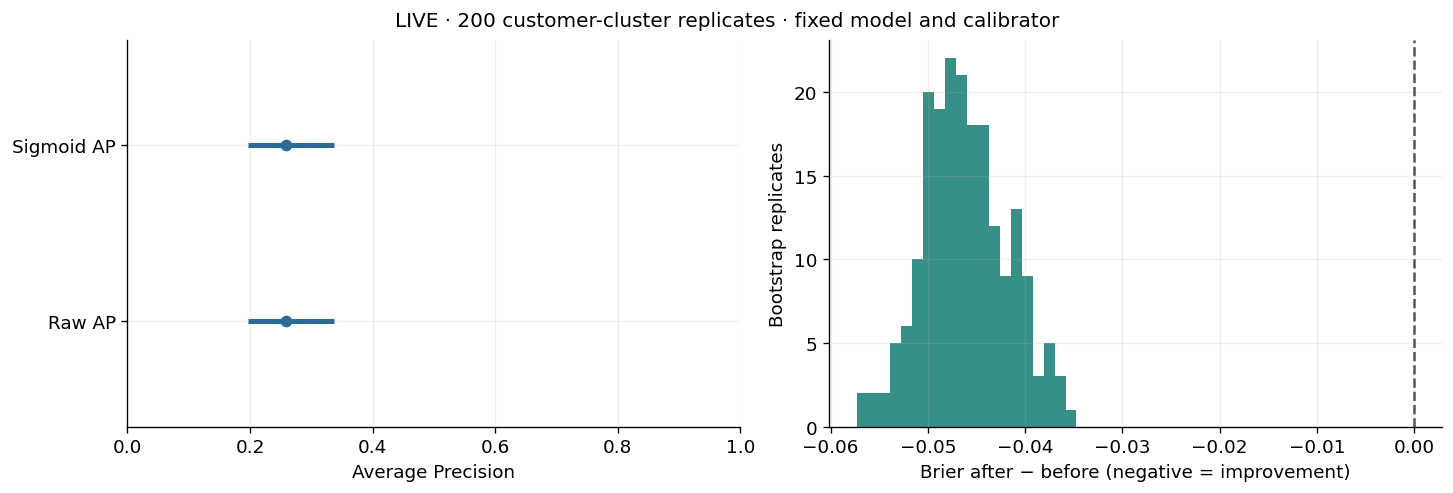

In [75]:
bootstrap, stability_summary = cluster_bootstrap(evaluation, config)
period_rows = []
for period, group in evaluation.groupby(pd.to_datetime(evaluation.application_date).dt.to_period("Q").astype(str)):
    for variant, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
        period_rows.append({"period": period, "variant": variant, **probability_metrics(group[TARGET], group[column])})
period_metrics = pd.DataFrame(period_rows)
display(period_metrics[["period", "variant", "rows", "positives", "average_precision", "brier", "ece"]].round(5))
stability_summary["period_ap_sample_sd"] = {v: float(g.average_precision.std(ddof=1)) for v, g in period_metrics.groupby("variant")}
print("Paired customer-cluster 95% percentile intervals:")
display(pd.DataFrame({key: stability_summary[key] for key in ("raw_ap", "calibrated_ap", "brier_change")}).T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for i, key in enumerate(("raw_ap", "calibrated_ap")):
    interval = stability_summary[key]
    point = calibration_metrics["raw" if i == 0 else "sigmoid"]["average_precision"]
    if interval is not None:
        axes[0].hlines(i, interval["lower"], interval["upper"], color="#2b6b98", lw=3)
    axes[0].plot(point, i, "o", color="#2b6b98")
axes[0].set(yticks=[0, 1], yticklabels=["Raw AP", "Sigmoid AP"], xlabel="Average Precision", xlim=(0, 1), ylim=(-.6, 1.6))
axes[1].hist(bootstrap.brier_change, bins=20, color="#137d72", alpha=.85)
axes[1].axvline(0, color="#555", linestyle="--"); axes[1].set(xlabel="Brier after − before (negative = improvement)", ylabel="Bootstrap replicates")
fig.suptitle(f"LIVE · {stability_summary['valid']} customer-cluster replicates · fixed model and calibrator", fontsize=12)
fig.savefig(ARTIFACTS / "stability_summary.png", bbox_inches="tight"); plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. Test whether the review zone fits capacity</h2>
<p>The raw threshold was selected on the policy role only under the 10×FN+FP loss and a 12% capacity ceiling. It is transported through the monotone sigmoid mapping; it is not reselected on evaluation and is not copied from a different Day 3 model.</p>
<p>The ±0.02 probability zone is a diagnostic band for near-threshold cases, not individual uncertainty. When combining it with risk flags, count the union once. Capacity can fail in a later period even before adding the zone.</p>
<p><code>CAPACITY_REVIEW_REQUIRED</code> is a valid finding. Do not raise the ceiling, hide rows or retune the threshold after seeing evaluation. A revised policy must be developed and evaluated with new evidence.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. اختبر ملاءمة منطقة المراجعة للسعة</h2>
<p>اختيرت العتبة الخام على دور policy فقط ضمن خسارة 10×FN+FP وسقف سعة 12%. تُنقل عبر تحويل sigmoid المتزايد، ولا يُعاد اختيارها على evaluation ولا تُنسخ من نموذج مختلف في اليوم الثالث.</p>
<p>منطقة الاحتمال ±0.02 نطاق تشخيصي للحالات القريبة من العتبة وليست عدم يقين فرديًا. عند جمعها مع إشارات المخاطر احسب اتحاد المجموعتين مرة واحدة. قد تفشل السعة في فترة لاحقة حتى قبل إضافة المنطقة.</p>
<p>ظهور <code>CAPACITY_REVIEW_REQUIRED</code> نتيجة صحيحة. لا ترفع السقف ولا تُخفِ صفوفًا ولا تعِد ضبط العتبة بعد رؤية التقييم. يجب تطوير السياسة المعدلة وتقييمها بدليل جديد.</p>
</td>
</tr>
</table>

,threshold,flagged,fn,fp,loss_units,capacity,feasible,calibrated_threshold,selection_role
0,0.588195,68,34,47,387.0,70,True,0.17331,policy


,period,rows,capacity,risk_flags,near_threshold,candidate_review,risk_within_capacity,candidate_within_capacity,loss_units
0,2024Q3,836,100,97,23,109,True,False,536.0
1,2024Q4,897,107,109,21,122,False,False,444.0


CAPACITY_REVIEW_REQUIRED | Do not retune on evaluation.


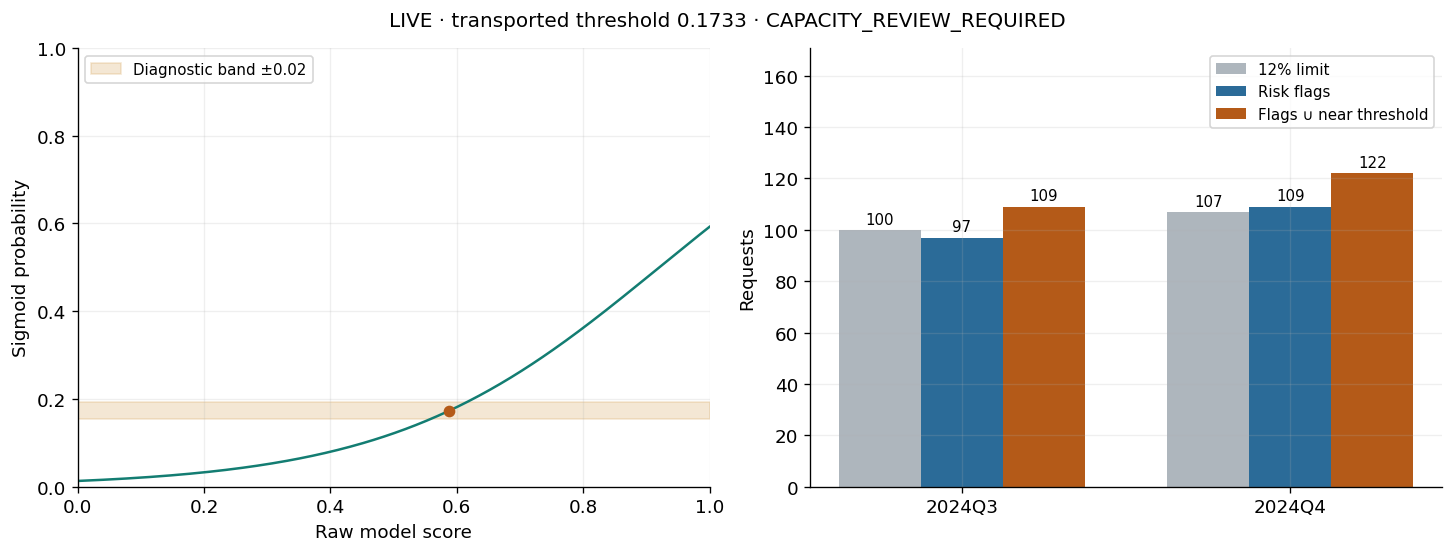

In [76]:
review_flags, capacity_audit, review_band = review_audit(evaluation, chosen_policy["threshold"],
    calibrated_threshold, config.review_half_width)
policy_status = "CAPACITY_REVIEW_REQUIRED" if not capacity_audit.candidate_within_capacity.all() else "WITHIN_OBSERVED_CAPACITY"
display(pd.DataFrame([{**chosen_policy, "calibrated_threshold": calibrated_threshold, "selection_role": "policy"}]))
display(capacity_audit)
print(policy_status, "| Do not retune on evaluation.")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
grid = np.linspace(0, 1, 300)
axes[0].plot(grid, map_probability(grid, mapping), color="#137d72")
axes[0].axhspan(review_band['lower'], review_band['upper'], color="#d7a354", alpha=.25, label="Diagnostic band ±0.02")
axes[0].plot(chosen_policy['threshold'], calibrated_threshold, 'o', color="#b45a18")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Raw model score", ylabel="Sigmoid probability")
axes[0].legend(loc="upper left", fontsize=9)
x = np.arange(len(capacity_audit))
for offset, column, label, color in [(-.25, 'capacity', '12% limit', '#aeb6bd'), (0, 'risk_flags', 'Risk flags', '#2b6b98'), (.25, 'candidate_review', 'Flags ∪ near threshold', '#b45a18')]:
    bars = axes[1].bar(x+offset, capacity_audit[column], width=.25, label=label, color=color)
    axes[1].bar_label(bars, padding=2, fontsize=9)
axes[1].set(xticks=x, xticklabels=capacity_audit.period, ylabel="Requests", ylim=(0, capacity_audit.candidate_review.max()*1.4))
axes[1].legend(fontsize=9)
fig.suptitle(f"LIVE · transported threshold {calibrated_threshold:.4f} · {policy_status}", fontsize=12)
fig.savefig(ARTIFACTS / "review_zone.png", bbox_inches="tight"); plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. Write the interpretation supported by your evidence</h2>
<p>Complete all six fields in <code>responses</code> and cite your measured values and denominators:</p>
<ol><li>global versus local explanation;</li><li>SHAP output unit and background;</li><li>limits of reason statements and correlated features;</li><li>calibration evidence on the separate period;</li><li>what the stability interval includes and excludes;</li><li>the review zone's effect on period capacity.</li></ol>
<p>Completeness changes the learner checkpoint to ready for review. It does not verify correctness and does not award an automatic grade.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. اكتب تفسيرًا تدعمه أدلتك</h2>
<p>أكمل الحقول الستة داخل <code>responses</code> واستشهد بالقيم المقاسة ومقاماتها:</p>
<ol><li>الفرق بين التفسير العام والمحلي؛</li><li>وحدة SHAP وخلفيته؛</li><li>حدود عبارات السبب والخصائص المترابطة؛</li><li>دليل المعايرة على الفترة المنفصلة؛</li><li>ما تشمله فترة الاستقرار وما تستبعده؛</li><li>أثر منطقة المراجعة في سعة كل فترة.</li></ol>
<p>يحوّل اكتمال النصوص بوابة المتدرب إلى جاهز للمراجعة، لكنه لا يتحقق من صحة الإجابات ولا يمنح درجة آلية.</p>
</td>
</tr>
</table>

In [77]:
responses = {
    "global_local": (
        "The global explanations show which features influence the model most across "
        "the evaluation data, while the local explanation describes the drivers of one "
        "specific high-score application. Globally, bureau_score had the largest mean "
        "absolute SHAP value (0.9042), followed by dti (0.5437) and loan_amount_sar "
        "(0.3490)."
    ),

    "output_units": (
        "TreeSHAP explains the raw LightGBM margin in log-odds, not probability points. "
        "The explanation uses the fixed evaluation sample and the model's SHAP background, "
        "so SHAP contributions should not be interpreted directly as changes in probability."
    ),

    "reason_limits": (
        "Local reason statements describe model associations for a specific application "
        "and should not be interpreted as causal explanations. Correlated features may "
        "share or redistribute importance, so an individual feature contribution should "
        "not be interpreted in isolation."
    ),

    "calibration_evidence": (
        "Calibration was evaluated on the separate calibration period containing 584 "
        "applications, including 40 positive cases. The sigmoid calibrator was learned "
        "only from this calibration period and then evaluated on later data. The stability "
        "analysis showed a Brier-score change between -0.054177 and -0.037409, indicating "
        "lower Brier loss after calibration in the bootstrap samples."
    ),

    "stability": (
        "The paired customer-cluster bootstrap used 200 customer-cluster replicates while "
        "keeping the fitted model and calibrator fixed. The 95% percentile interval for "
        "raw AP was 0.197442 to 0.337854, and calibrated AP had the same interval. "
        "The interval captures sampling variability in the evaluation customers, but it "
        "does not include uncertainty from refitting the model or recalibrating it."
    ),

    "review_capacity": (
        "The selected raw threshold was 0.588195 and flagged 68 applications, with an "
        "overall capacity of 70. However, the near-threshold review zone increased the "
        "candidate review workload beyond period capacity. In 2024Q3, capacity was 100 "
        "and candidate review was 109; in 2024Q4, capacity was 107 and candidate review "
        "was 122. Therefore, the result was CAPACITY_REVIEW_REQUIRED."
    )
}

checkpoint = reflection_check(responses, EXPLANATION_SOURCE)
print(checkpoint["status"], "| Fields to complete:", checkpoint["missing"])

READY_FOR_REVIEW | Fields to complete: []


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>10. Export the report and evidence bundle</h2>
<p>Re-run the export cell after completing <code>responses</code>. Download <code>artifacts/day4_artifacts.zip</code> and keep its <code>artifacts/</code> and <code>reports/</code> structure. Save the executed notebook as <code>notebooks/04_explain_calibrate.ipynb</code>.</p>
<p>The bundle contains 12 CSV tables, six analysis JSON files plus the environment record, a compressed NPZ of complete SHAP values, the LightGBM model text, six PNG figures and <code>reports/INTERPRETABILITY_REPORT.md</code>.</p>
<p>Read probability CSV files with <code>float_precision="round_trip"</code> when exact round trips matter. A technically successful run can still require learner work or capacity review. Educational-example mode is not submittable and is blocked in assessment mode.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>10. صدّر التقرير وحزمة الأدلة</h2>
<p>أعد تشغيل خلية التصدير بعد إكمال <code>responses</code>. نزّل <code>artifacts/day4_artifacts.zip</code> واحتفظ بهيكل <code>artifacts/</code> و<code>reports/</code>. احفظ الدفتر المنفذ باسم <code>notebooks/04_explain_calibrate.ipynb</code>.</p>
<p>تضم الحزمة 12 جدول CSV وستة ملفات JSON تحليلية إضافة إلى سجل البيئة، وملف NPZ مضغوط لقيم SHAP الكاملة، ونص نموذج LightGBM، وستة رسوم PNG، وملف <code>reports/INTERPRETABILITY_REPORT.md</code>.</p>
<p>استخدم <code>float_precision="round_trip"</code> عند إعادة قراءة ملفات الاحتمالات إذا كانت الاستعادة الدقيقة مهمة. قد ينجح التشغيل تقنيًا مع بقاء عمل على المتدرب أو مراجعة للسعة. وضع المثال التعليمي غير صالح للتسليم ويُحظر في وضع التقييم.</p>
</td>
</tr>
</table>

In [78]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, np.ndarray)): return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, (np.bool_,)): return bool(value)
    if isinstance(value, (float, np.floating)): return float(value) if np.isfinite(value) else None
    return value

technical_status = "TECHNICAL_READY" if EXPLANATION_SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
calibration_payload = {"source": "LIVE", "evaluation_role": "evaluation", "metrics": calibration_metrics,
    "mapping": mapping, "policy_selection": chosen_policy, "calibrated_threshold": calibrated_threshold,
    "review_band": review_band, "capacity_status": policy_status, "brier_change": brier_delta, "ece_change": ece_delta,
    "prior_course_exposure": True, "not_a_final_untouched_test": True}
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "explanation_source": EXPLANATION_SOURCE, "model_calibration_source": "LIVE", "config": asdict(config),
    "assessment_mode": ASSESSMENT_MODE, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "previous_support": PREVIOUS_SUPPORT, "data_revision": COURSE_REVISION, "python": platform.python_version(),
    "elapsed_seconds": round(time.perf_counter()-RUN_STARTED, 2), "capacity_status": policy_status,
    "challenge_used_for_modeling": False, "no_automatic_grade": True}
csv_outputs = {"day4_roles.csv": assignments, "day4_predictions.csv": predictions,
    "permutation_importance.csv": permutation, "day4_shap_global.csv": shap_global.assign(source=EXPLANATION_SOURCE),
    "day4_reason_codes.csv": reasons, "day4_local_stability.csv": local_checks,
    "day4_reliability_bins.csv": reliability, "day4_period_metrics.csv": period_metrics,
    "day4_bootstrap.csv": bootstrap, "day4_policy_sweep.csv": policy_sweep,
    "day4_review_flags.csv": review_flags, "day4_capacity.csv": capacity_audit}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
np.savez_compressed(ARTIFACTS / "shap_values_sample.npz", **shap_arrays)
model.named_steps["model"].booster_.save_model(str(ARTIFACTS / "day4_model.txt"))
json_outputs = {"calibration_metrics.json": calibration_payload, "day4_shap_metadata.json": shap_metadata,
    "day4_stability_summary.json": stability_summary, "day4_provenance.json": provenance,
    "day4_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day4_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
status_text = "مثال تعليمي غير صالح للتسليم كتجربة شخصية" if EXPLANATION_SOURCE != "LIVE" else ("مسودة — أكمل تفسيرك" if checkpoint['missing'] else "جاهز للمراجعة؛ لا يعني اعتمادًا أو درجة")
reason_text = "\n".join(f"- {r.reason_ar} (SHAP={r.contribution_log_odds:+.4f} log-odds؛ قيمة معوضة: {r.was_imputed})" for r in reasons.itertuples())
capacity_text = "\n".join(f"- {r.period}: السقف {r.capacity}، الإشارات {r.risk_flags}، اتحاد المراجعة {r.candidate_review}." for r in capacity_audit.itertuples())
report = f"""# تقريرك: التفسير والمعايرة — Tamweel Lite

**الحالة:** {status_text}

**مصدر التفسير:** {EXPLANATION_SOURCE}. **النموذج والمعايرة:** LIVE. **السعة:** {policy_status}.

## النموذج والأدوار
LightGBM موزون، {config.trees} شجرة. الهدف حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. الأدوار منفصلة زمنيًا وبالعملاء: تدريب {len(parts['fit'])}، معايرة {len(parts['calibration'])} ({int(parts['calibration'][TARGET].sum())} موجب)، سياسة {len(parts['policy'])}، تقييم {len(evaluation)}. الفجوات والتداخلات مستبعدة. سبق استخدام بيانات التقييم في الدورة، فهي ليست اختبارًا نهائيًا لم يمسّ.

## التفسير العام والمحلي
Permutation يقيس انخفاضAP على التقييم؛ إشارات المنطقة تُبدّل معًا. SHAP يفسر النموذج الخام بوحدةlog-odds وخلفية مسارات أشجار التدريب. base+sum(SHAP)=raw margin، ثمsigmoid للمجموع فقط. القيم ليست نقاط احتمال ولا تفسيرًا مباشرًا للنموذج المعاير.

{answer('global_local')}

{answer('output_units')}

الطلب الاصطناعي {local_id}: الدرجة الخام {raw_local:.5f} والاحتمال المعاير {cal_local:.5f}. اختير أعلى درجة داخل عينةSHAP دون استخدام النتيجة الفعلية.
{reason_text}

{answer('reason_limits')}

## دليل المعايرة
على {len(evaluation)} صفًا و{int(evaluation[TARGET].sum())} موجب: Brier {calibration_metrics['raw']['brier']:.6f} → {calibration_metrics['sigmoid']['brier']:.6f}؛ ECE {calibration_metrics['raw']['ece']:.6f} → {calibration_metrics['sigmoid']['ece']:.6f}. عشر حاويات متساوية العرض مع أعدادها فيday4_reliability_bins.csv. AP {calibration_metrics['raw']['average_precision']:.6f} → {calibration_metrics['sigmoid']['average_precision']:.6f}؛ ROC-AUC {calibration_metrics['raw']['roc_auc']:.6f} → {calibration_metrics['sigmoid']['roc_auc']:.6f}. هذه نتائج هذه العينة وليست ضمانًا لتحسن مستقبلي.

{answer('calibration_evidence')}

## الاستقرار
{stability_summary['valid']} تكرارbootstrap صالح بسحب العملاء؛ فترات مئينية95% مع تثبيت النموذج والمعاير. لا تشمل تعلم النموذج أو المعايرة أو الانجراف المستقبلي، ولا تصف احتمال فرد. انحرافAP بين ربعي التقييم وصفي فقط. اختبارbureau_score±1 {'نُفذ؛ راجع day4_local_stability.csv' if EXPLANATION_SOURCE == 'LIVE' else 'لم ينفذ في وضع المثال'}.

{answer('stability')}

## العتبة ومنطقة المراجعة
العتبة الخام {chosen_policy['threshold']!r} اختيرت علىpolicy بخسارة10×FN+FP وسقف12% ثم نُقلت إلى {calibrated_threshold!r}. لم تعدل باستخدام التقييم. المنطقة[{review_band['lower']:.5f}, {review_band['upper']:.5f}] تشخيصية بعرض±0.02 وليست فترة ثقة. الاتحاد يحسب الطلب مرة واحدة.
{capacity_text}

{answer('review_capacity')}

عند تجاوز السعة، وثّق الحاجة إلى تصميم سياسة جديدة على بيانات تطوير وتقييمها بدليل جديد. لا ترفع السقف ولا تقص الحالات بعد رؤية النتيجة. التفسير ليس سببية أو شهادة عدالة، والخسارة وحدات تعليمية لا رسوم أو خصم درجات. لا يستخدم هذا التمرين لتمويل حقيقي.
"""
(REPORTS / "INTERPRETABILITY_REPORT.md").write_text(report, encoding="utf-8")
figures = ["permutation_importance.png", "shap_beeswarm.png", "shap_waterfall.png", "reliability_curve.png", "stability_summary.png", "review_zone.png"]
artifact_files = list(csv_outputs) + list(json_outputs) + figures + ["environment.json", "shap_values_sample.npz", "day4_model.txt"]
with zipfile.ZipFile(ARTIFACTS / "day4_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files: bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "INTERPRETABILITY_REPORT.md", "reports/INTERPRETABILITY_REPORT.md")
print(f"{technical_status} | {checkpoint['status']} | {EXPLANATION_SOURCE} | CPU")
print(f"Saved {len(artifact_files)+1} files in day4_artifacts.zip | {policy_status}")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | CPU
Saved 28 files in day4_artifacts.zip | CAPACITY_REVIEW_REQUIRED


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Before moving to Day 5</h2>
<p>Open all six figures and verify units, denominators, labels and explanation source. Be able to explain why one monotone mapping can preserve rank, why SHAP contributions do not establish causality and why near-threshold review needs a separate capacity calculation.</p>
<p>If an educational SHAP example was used, rerun live SHAP on CPU before submission; never present the example as your own experiment.</p>
<p><a href="https://github.com/almiyead-rgb/sda-dsc-211-student-template/blob/main/DAY4_GUIDE.md">Day 4 guide</a> · <a href="https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html">TreeExplainer output units</a> · <a href="https://scikit-learn.org/1.6/modules/generated/sklearn.calibration.CalibratedClassifierCV.html">Frozen-model calibration</a></p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>قبل الانتقال إلى اليوم الخامس</h2>
<p>افتح الرسوم الستة وتحقق من الوحدات والمقامات والعناوين ومصدر التفسير. يجب أن تستطيع شرح سبب محافظة تحويل متزايد واحد على الترتيب، ولماذا لا تثبت مساهمات SHAP السببية، ولماذا تحتاج مراجعة الحالات القريبة إلى حساب مستقل للسعة.</p>
<p>إذا استُخدم مثال SHAP التعليمي فأعد تشغيل SHAP المباشر على CPU قبل التسليم، ولا تعرض المثال بوصفه تجربتك.</p>
<p><a href="https://github.com/almiyead-rgb/sda-dsc-211-student-template/blob/main/DAY4_GUIDE.md">دليل اليوم الرابع</a> · <a href="https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html">وحدات TreeExplainer</a> · <a href="https://scikit-learn.org/1.6/modules/generated/sklearn.calibration.CalibratedClassifierCV.html">معايرة نموذج مجمد</a></p>
</td>
</tr>
</table>